# Image Phrase Compilation

Per-image compilation of **original phrases**, their **sentiments**, and extracted **word stems**.

### Pipeline
1. Load `image_phrase_word_mapping.csv` (one row per image) as the base table
2. Add **originalPhrases** from `image_compiled_phrases.csv` (pre-compiled per image)
3. Add **originalSentiments** from `term_mapping.csv` (OriginalSign, matching phrase order)
4. Drop `words_from_humanCurated` and `words_from_finalPhrases`
5. Extract **originalStems** and **originalStemPOS** from original phrases (validated against `unique_stems.csv`)
6. Save to `phrase_reduction_v2/image_compiled_phrases.csv`

### Final column order
`imageName, imageURL, VisType, NormalizedVC, Topics, SubTopics, originalPhrases, originalSentiments, originalStems, originalStemPOS, objectWords, actionWords, humanCuratedPhrases, finalPhrases`

In [61]:
import pandas as pd
import re
import spacy
from nltk.stem import SnowballStemmer
from collections import defaultdict

nlp = spacy.load('en_core_web_sm')
stemmer = SnowballStemmer('english')

# ── 9 standard VisType names (used across all pivots) ───────────────────────────
vistype_names = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
                 'Line', 'Node-link', 'Point', 'Text']

# ── Load all source tables ──────────────────────────────────────────────────────
df_base = pd.read_csv('phrase_reduction_v2/image_phrase_word_mapping.csv')
df_compiled = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')
df_term = pd.read_csv('figures/term_mapping.csv')
df_stems = pd.read_csv('phrase_reduction_v2/stem_dictionary.csv').rename(columns={'stem': 'OriginalWord', 'POS': 'OriginalPOS'})
df_shortlist = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')

print(f'Base table:            {len(df_base)} images, columns: {df_base.columns.tolist()}')
print(f'Compiled phrases:      {len(df_compiled)} images, originalPhrases coverage: {(df_compiled["originalPhrases"].notna() & (df_compiled["originalPhrases"] != "")).sum()}')
print(f'Term mapping:          {len(df_term)} entries')

print(f'Unique stems (Original): {df_stems["OriginalWord"].dropna().nunique()} unique words')
print(f'Phrase shortlist:      {len(df_shortlist)} final phrases across {df_shortlist["Topic"].nunique()} topics')

Base table:            520 images, columns: ['imageName', 'imageURL', 'VisType', 'Topics', 'humanCuratedPhrases', 'SubTopics']
Compiled phrases:      520 images, originalPhrases coverage: 520
Term mapping:          1708 entries
Unique stems (Original): 668 unique words
Phrase shortlist:      19 final phrases across 7 topics


## Add Original Phrases & Sentiments

- Load per-image original phrases from `image_compiled_phrases.csv`
- Look up each phrase's sentiment (`OriginalSign`) from `term_mapping`
- Drop `words_from_humanCurated` and `words_from_finalPhrases`
- Save intermediate result

In [62]:
import json

# ── Build per-image original phrases from compiled table ─────────────────────────
img_originals = {}
for _, row in df_compiled.iterrows():
    img = row['imageName']
    op = row.get('originalPhrases', '')
    if isinstance(op, str) and op.strip():
        img_originals[img] = op.strip()

# ── Fallback: for images missing from df_compiled, extract phrases from sheet 1103808983 ──
# The ExtractedPhrases columns contain JSON: {"Topic": ["(+) phrase", ...], ...}
# We parse the JSON, strip the (+)/(-) prefix to get clean phrases, and store sentiments.
missing_imgs = set(df_base['imageName']) - set(img_originals.keys())
fallback_sentiments = {}  # img -> list of sentiment strings matching phrase order

def parse_extracted_json(raw):
    """Parse a JSON-format extracted phrases cell.
    Returns list of (phrase, sentiment) tuples."""
    results = []
    raw = raw.strip()
    if not raw or raw == 'nan' or raw == '{}':
        return results
    if not raw.startswith('{'):
        # Plain text fallback (comma-separated)
        for p in re.split(r',(?![^(]*\))', raw):
            p = p.strip()
            if p:
                results.append((p, '?'))
        return results
    try:
        obj = json.loads(raw)
    except json.JSONDecodeError:
        # Try fixing common issues: semicolons used as separators instead of commas
        fixed = raw.replace(';\n', ',\n').replace('; "', ', "')
        try:
            obj = json.loads(fixed)
        except json.JSONDecodeError:
            # Last resort: treat as plain text
            for p in re.split(r'[;,]', raw):
                p = p.strip().strip('"').strip('{').strip('}').strip()
                if p and not p.startswith('"') and len(p) > 3:
                    results.append((p, '?'))
            return results
    if isinstance(obj, dict):
        for topic, phrases in obj.items():
            if isinstance(phrases, list):
                for entry in phrases:
                    if not isinstance(entry, str):
                        continue
                    entry = entry.strip()
                    # Extract sentiment prefix: "(+) phrase" or "(-) phrase"
                    sent = '?'
                    m = re.match(r'^\(([+-])\)\s*', entry)
                    if m:
                        sent = f'({m.group(1)})'
                        entry = entry[m.end():].strip()
                    if entry:
                        results.append((entry, sent))
    return results

if missing_imgs:
    _spreadsheet_id = '1cVCOfBjHmcvsyrn7U0CbXoBSksF4JDRqWYm-ZJPbL4k'
    _df_pairs = pd.read_csv(
        f'https://docs.google.com/spreadsheets/d/{_spreadsheet_id}/export?gid=1540814304&format=csv'
    )
    # Collect extracted phrases per image from both sides of each comparison
    _img_extracted = defaultdict(list)  # img -> list of (phrase, sentiment)
    for _, row in _df_pairs.iterrows():
        for img_col, phrase_col in [
            ('moreComplexImageName', 'ExtractedPhrasesMoreComplex'),
            ('lessComplexImageName', 'ExtractedPhrasesLessComplex'),
        ]:
            img = str(row.get(img_col, '')).strip()
            raw = str(row.get(phrase_col, '')).strip()
            if img in missing_imgs and raw and raw != 'nan':
                parsed = parse_extracted_json(raw)
                _img_extracted[img].extend(parsed)

    n_filled = 0
    for img in missing_imgs:
        if img in _img_extracted:
            # Deduplicate while preserving order
            seen = set()
            deduped_phrases = []
            deduped_sents = []
            for phrase, sent in _img_extracted[img]:
                if phrase not in seen:
                    seen.add(phrase)
                    deduped_phrases.append(phrase)
                    deduped_sents.append(sent)
            if deduped_phrases:
                img_originals[img] = '; '.join(deduped_phrases)
                fallback_sentiments[img] = deduped_sents
                n_filled += 1
    print(f'Fallback from sheet 1540814304: {n_filled}/{len(missing_imgs)} missing images got original phrases')
    # Show a few examples
    for img in sorted(fallback_sentiments)[:3]:
        print(f'  {img}: phrases={img_originals[img][:80]}...')
        print(f'               sents={fallback_sentiments[img]}')

# ── Build sentiment lookup from term_mapping ────────────────────────────────────
sentiment_lookup = {}
for _, row in df_term.iterrows():
    orig = row['original']
    sign = row['OriginalSign']
    if isinstance(orig, str) and isinstance(sign, str):
        sentiment_lookup[orig.strip()] = sign.strip()

print(f'Sentiment lookup: {len(sentiment_lookup)} original phrases mapped')

# ── Add columns to df_base ──────────────────────────────────────────────────────
df_base['originalPhrases'] = df_base['imageName'].map(img_originals).fillna('')

def get_sentiments(row):
    img = row['imageName']
    phrases_str = row['originalPhrases']
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return ''
    # Use fallback sentiments if available (extracted from JSON)
    if img in fallback_sentiments:
        return '; '.join(fallback_sentiments[img])
    # Otherwise look up in term_mapping
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    signs = [sentiment_lookup.get(p, '?') for p in phrases]
    return '; '.join(signs)

df_base['originalSentiments'] = df_base.apply(get_sentiments, axis=1)

# ── Drop word columns ──────────────────────────────────────────────────────────
df_base = df_base.drop(columns=['words_from_humanCurated', 'words_from_finalPhrases'], errors='ignore')

# ── Coverage stats ──────────────────────────────────────────────────────────────
n_with = (df_base['originalPhrases'] != '').sum()
n_without = (df_base['originalPhrases'] == '').sum()
print(f'Images with original phrases: {n_with}, without: {n_without}')

# Sentiment coverage
all_orig_phrases = []
for s in df_base['originalPhrases']:
    if isinstance(s, str) and s.strip():
        all_orig_phrases.extend([p.strip() for p in s.split(';') if p.strip()])
n_found = sum(1 for p in all_orig_phrases if p in sentiment_lookup)
n_fallback = sum(len(v) for v in fallback_sentiments.values())
print(f'Sentiment coverage: {n_found}/{len(all_orig_phrases)} from term_mapping, {n_fallback} from JSON extraction')

n_unknown = sum(1 for s in df_base['originalSentiments'] 
                for x in s.split(';') if x.strip() == '?')
print(f'Unknown sentiments (?): {n_unknown}')

# Show sample
df_base[['imageName', 'originalPhrases', 'originalSentiments']].tail(10)

Sentiment lookup: 1704 original phrases mapped
Images with original phrases: 520, without: 0
Sentiment coverage: 1948/1970 from term_mapping, 0 from JSON extraction
Unknown sentiments (?): 22


,imageName,originalPhrases,originalSentiments
510,visMost533.png,lacks context; requires more understanding; ma...,(+); (+); (+); (+); (+); (+); (+)
511,VisC.73.8.png,difficult to ascertain,(+)
512,InfoVisC.65.5(2).png,nature of this info; could be difficult; a lot...,(+); (+); (+); (+); (+); (+); (+); (+); (+)
513,VisC.383.7.png,darker/denser area; pattern; receeding horizon...,(+); (+); (+)
514,vis567.png,all new to me; not common sense; don't understand,(+); (+); (+)
515,VASTJ.1612.1.png,words are difficult to see; two different colo...,(+); (+); (+)
516,InfoVisC.24.8(1).png,Values - Graphic and vales have logic; can see...,(+); (-)
517,InfoVisJ.449.8.png,Way more information; more full of stuff; vari...,(+); (+); (+); (+)
518,InfoVisJ.1149.6(1).png,high information density; large amount of text...,(+); (+); (+); (+); (+); (+); (+)
519,VASTJ.1698.5(4).png,lines crossing; information depicted more gran...,(+); (+); (+); (+); (+); (+); (+)


## Extract Word Stems from Original Phrases

Tokenize each image's original phrases with spaCy, stem with SnowballStemmer, map to representative
words via `stem_to_word`, and validate against the OriginalWord column in `unique_stems.csv`.

In [63]:
# ── Stemming helpers (reused from KeywordExtraction_v2) ─────────────────────────
WHITELIST_TOKENS = {'2d', '3d', '2d/3d'}

def is_valid_token(token):
    """Check if a spaCy token is a valid content word."""
    text = token.text.lower()
    if text in WHITELIST_TOKENS:
        return True
    if token.is_stop or token.is_punct or token.is_space:
        return False
    if token.pos_ == 'NUM':
        return False
    if not re.match(r'^[a-z]+(-[a-z]+)*$', text):
        return False
    if len(text) <= 1:
        return False
    return True

# ── Build global stem → representative word mapping from all Original phrases ───
all_original_phrases = df_term['original'].dropna().str.strip().unique()

stem_to_word = {}
for phrase in all_original_phrases:
    doc = nlp(phrase)
    for token in doc:
        if is_valid_token(token):
            word = token.lemma_.lower()
            stem = stemmer.stem(word)
            if stem not in stem_to_word or len(word) < len(stem_to_word[stem]):
                stem_to_word[stem] = word

print(f'Built stem_to_word mapping: {len(stem_to_word)} stems')

# ── Build valid stems set from stem_dictionary.csv (OriginalWord column) ────────
valid_original_words = set(df_stems['OriginalWord'].dropna().str.strip())
print(f'Valid OriginalWords in stem_dictionary.csv: {len(valid_original_words)}')

# ── Build word→POS lookup from stem_dictionary.csv ─────────────────────────────
# POS column may contain comma-separated values like "ADJ, NOUN, VERB"
word_pos_lookup = defaultdict(set)
for _, row in df_stems[['OriginalWord', 'OriginalPOS']].dropna().iterrows():
    word = row['OriginalWord'].strip()
    for pos in str(row['OriginalPOS']).split(','):
        pos = pos.strip()
        if pos:
            word_pos_lookup[word].add(pos)

# ── Extract stems for each image ───────────────────────────────────────────────
def extract_stems_and_pos(phrases_str):
    """From semicolon-separated original phrases, extract unique (word, POS) pairs."""
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return '', ''
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    stems_seen = set()
    words = []
    pos_tags = []
    for phrase in phrases:
        doc = nlp(phrase)
        for token in doc:
            if is_valid_token(token):
                word = token.lemma_.lower()
                stem = stemmer.stem(word)
                if stem not in stems_seen:
                    stems_seen.add(stem)
                    rep_word = stem_to_word.get(stem, word)
                    # Only include if it's a valid OriginalWord
                    if rep_word in valid_original_words:
                        words.append(rep_word)
                        # Use the POS from context, but validate against unique_stems
                        ctx_pos = token.pos_
                        known_pos = word_pos_lookup.get(rep_word, set())
                        if ctx_pos in known_pos:
                            pos_tags.append(ctx_pos)
                        elif known_pos:
                            pos_tags.append(sorted(known_pos)[0])
                        else:
                            pos_tags.append(ctx_pos)
    return '; '.join(words), '; '.join(pos_tags)

results = df_base['originalPhrases'].apply(extract_stems_and_pos)
df_base['originalStems'] = results.apply(lambda x: x[0])
df_base['originalStemPOS'] = results.apply(lambda x: x[1])

# ── Stats ──────────────────────────────────────────────────────────────────────
n_with_stems = (df_base['originalStems'] != '').sum()
avg_stems = df_base['originalStems'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'Images with stems: {n_with_stems}/{len(df_base)}')

print(f'Avg stems per image: {avg_stems:.1f}')
df_base[['imageName', 'originalPhrases', 'originalStems', 'originalStemPOS']].head(5)

# Show a few examples

Built stem_to_word mapping: 725 stems
Valid OriginalWords in stem_dictionary.csv: 668
Images with stems: 518/520
Avg stems per image: 6.4


,imageName,originalPhrases,originalStems,originalStemPOS
0,VisJ.1431.7.png,no way of knowing what it is showing me; a lin...,way; know; show; line; point,NOUN; VERB; VERB; NOUN; NOUN
1,InfoVisJ.2412.7.png,Simplistic symbol,simplistic; symbol,ADJ; NOUN
2,SciVisJ.995.5.png,axes; numerical values; information presenting...,axis; numerous; value; information; present; p...,NOUN; PROPN; NOUN; NOUN; VERB; NOUN; NOUN; VERB
3,VisC.503.6.png,bar graphs; circle graphs; easy to understand,bar; graph; circle; easy; understand,NOUN; NOUN; PROPN; ADJ; VERB
4,VisC.199.5.png,less time consuming; make sense.; more easily ...,time; consume; sense; easily; understand,NOUN; VERB; NOUN; ADV; VERB


## Extract Object Words & Action Words

Use spaCy POS tagging on each image's original phrases to extract:
- **objectWords** — nouns (`NOUN`, `PROPN`)
- **actionWords** — verbs (`VERB`)

In [64]:
# ── Extract object (noun) and action (verb) words from original phrases ─────────
OBJECT_POS = {'NOUN', 'PROPN'}
ACTION_POS = {'VERB'}

def extract_objects_and_actions(phrases_str):
    """Extract unique object words (nouns) and action words (verbs) from original phrases."""
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return '', ''
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    obj_seen = set()
    act_seen = set()
    objects = []
    actions = []
    for phrase in phrases:
        doc = nlp(phrase)
        for token in doc:
            if not is_valid_token(token):
                continue
            lemma = token.lemma_.lower()
            if token.pos_ in OBJECT_POS and lemma not in obj_seen:
                obj_seen.add(lemma)
                objects.append(lemma)
            elif token.pos_ in ACTION_POS and lemma not in act_seen:
                act_seen.add(lemma)
                actions.append(lemma)
    return '; '.join(objects), '; '.join(actions)

oa_results = df_base['originalPhrases'].apply(extract_objects_and_actions)
df_base['objectWords'] = oa_results.apply(lambda x: x[0])
df_base['actionWords'] = oa_results.apply(lambda x: x[1])

# ── Stats ──────────────────────────────────────────────────────────────────────
n_obj = (df_base['objectWords'] != '').sum()
n_act = (df_base['actionWords'] != '').sum()
avg_obj = df_base['objectWords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
avg_act = df_base['actionWords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'Images with object words: {n_obj}/{len(df_base)}, avg: {avg_obj:.1f}')
print(f'Images with action words: {n_act}/{len(df_base)}, avg: {avg_act:.1f}')

df_base[['imageName', 'originalPhrases', 'objectWords', 'actionWords']].head(5)

Images with object words: 477/520, avg: 3.7
Images with action words: 323/520, avg: 1.2


,imageName,originalPhrases,objectWords,actionWords
0,VisJ.1431.7.png,no way of knowing what it is showing me; a lin...,way; line; point,know; show
1,InfoVisJ.2412.7.png,Simplistic symbol,symbol,
2,SciVisJ.995.5.png,axes; numerical values; information presenting...,axis; numerical; value; information; provoke; ...,present; understand
3,VisC.503.6.png,bar graphs; circle graphs; easy to understand,bar; graph; circle,understand
4,VisC.199.5.png,less time consuming; make sense.; more easily ...,time; sense,consume; understand


## Add Raw User Comments

Load paired-comparison data from sheet `1540814304`. Each row is a pair: `moreComplexImageName` ↔ `lessComplexImageName`.
For each image, collect all raw user comments where it appeared (from `CommentCollectedOnMoreComplexFig` or `CommentCollectedOnLessComplexFig`), deduplicated and semicolon-separated.

In [65]:
# ── Load paired-comparison sheet with raw user comments ─────────────────────────
spreadsheet_id = '1cVCOfBjHmcvsyrn7U0CbXoBSksF4JDRqWYm-ZJPbL4k'
df_pairs = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid=1540814304&format=csv'
)
print(f'Paired comparisons: {len(df_pairs)} rows')
print(f'Columns of interest: moreComplexImageName, lessComplexImageName, '
      f'CommentCollectedOnMoreComplexFig, CommentCollectedOnLessComplexFig')

# ── Collect all raw comments per image ──────────────────────────────────────────
from collections import defaultdict

img_comments = defaultdict(list)

for _, row in df_pairs.iterrows():
    more_img = row.get('moreComplexImageName', '')
    less_img = row.get('lessComplexImageName', '')
    more_comment = row.get('CommentCollectedOnMoreComplexFig', '')
    less_comment = row.get('CommentCollectedOnLessComplexFig', '')

    if isinstance(more_img, str) and more_img.strip() and isinstance(more_comment, str) and more_comment.strip():
        img_comments[more_img.strip()].append(more_comment.strip())
    if isinstance(less_img, str) and less_img.strip() and isinstance(less_comment, str) and less_comment.strip():
        img_comments[less_img.strip()].append(less_comment.strip())

# Deduplicate per image while preserving order
img_comments_dedup = {}
for img, comments in img_comments.items():
    seen = set()
    unique = []
    for c in comments:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    img_comments_dedup[img] = '; '.join(unique)

df_base['rawUserComments'] = df_base['imageName'].map(img_comments_dedup).fillna('')

# ── Stats ──────────────────────────────────────────────────────────────────────
n_with = (df_base['rawUserComments'] != '').sum()
n_without = (df_base['rawUserComments'] == '').sum()
avg_comments = df_base['rawUserComments'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'\nImages with raw user comments: {n_with}/{len(df_base)}')
print(f'Images without: {n_without}')
print(f'Avg comments per image: {avg_comments:.1f}')

df_base[['imageName', 'rawUserComments']].head(5)

Paired comparisons: 698 rows
Columns of interest: moreComplexImageName, lessComplexImageName, CommentCollectedOnMoreComplexFig, CommentCollectedOnLessComplexFig

Images with raw user comments: 501/520
Images without: 19
Avg comments per image: 1.9


,imageName,rawUserComments
0,VisJ.1431.7.png,"just an image to me, I have no way of knowing..."
1,InfoVisJ.2412.7.png,Simplistic symbol
2,SciVisJ.995.5.png,The image I chose shows what information the g...
3,VisC.503.6.png,The graph has more information and looks compl...
4,VisC.199.5.png,"more easily understood, less time consuming, m..."


## Save Final Table

In [67]:
import gc; gc.collect()

# ── Load sheet 1429789806 to get canonical image order ───────────────────────────
# This sheet is in the OTHER spreadsheet (1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc)
order_spreadsheet_id = '1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc'
df_order = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{order_spreadsheet_id}/export?gid=1429789806&format=csv'
)
print(f'Order sheet: {len(df_order)} rows, {len(df_order.columns)} columns')
print(f'Columns: {df_order.columns.tolist()}')

# ── Load NormalizedVC from the full VC spreadsheet (covers all images) ──────────
vis_map = pd.read_csv(
    'https://docs.google.com/spreadsheets/d/1N6nK03QiPAM6AELb9kC3beETnKmG6u23/export?gid=67202923&format=csv'
)
print(f'\nVC spreadsheet: {len(vis_map)} rows')
vis_map = vis_map[['ImageName', 'NormalizedVC']].rename(columns={'ImageName': 'imageName'})
print(f'vis_map: {len(vis_map)} images with NormalizedVC')

# ── Merge finalPhrases from image_final_phrases.csv ─────────────────────────────
_df_final = pd.read_csv('phrase_reduction_v2/image_final_phrases.csv')[['imageName', 'finalPhrases']]
if 'finalPhrases' in df_base.columns:
    df_base = df_base.drop(columns='finalPhrases')
df_base = df_base.merge(_df_final, on='imageName', how='left')
df_base['finalPhrases'] = df_base['finalPhrases'].fillna('')
del _df_final

# ── Merge NormalizedVC from vis_map (covers all images), reorder columns, and save ──
if 'NormalizedVC' in df_base.columns:
    df_base = df_base.drop(columns='NormalizedVC')
df_base = df_base.merge(vis_map[['imageName', 'NormalizedVC']], on='imageName', how='left')

# Report coverage
n_vc = df_base['NormalizedVC'].notna().sum()
print(f'NormalizedVC coverage: {n_vc}/{len(df_base)} images')

final_cols = [
    'imageName', 'imageURL', 'VisType', 'NormalizedVC', 'Topics', 'SubTopics',
    'rawUserComments',
    'originalPhrases', 'originalSentiments',
    'originalStems', 'originalStemPOS',
    'objectWords', 'actionWords',
    'humanCuratedPhrases', 'finalPhrases',
]
df_out = df_base[final_cols]

# ── Reorder rows to match canonical image order from sheet 1429789806 ───────────
image_order = df_order['imageName'].tolist()
order_map = {name: i for i, name in enumerate(image_order)}
df_out = df_out.copy()
df_out['_sort_order'] = df_out['imageName'].map(order_map)
# Images not in the order sheet go to the end
df_out = df_out.sort_values('_sort_order', na_position='last').drop(columns='_sort_order').reset_index(drop=True)

csv_path = 'phrase_reduction_v2/image_compiled_phrases.csv'
df_out.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}  ({len(df_out)} images, {len(final_cols)} columns)')
print(f'Columns: {df_out.columns.tolist()}')
n_matched = df_out['imageName'].isin(set(image_order)).sum()
print(f'Row order: {n_matched}/{len(df_out)} images matched canonical order from sheet 1429789806')

# Check for any remaining empty fields in tail rows
tail = df_out.tail(30)
n_no_vc = tail['NormalizedVC'].isna().sum()
n_no_phrases = (tail['originalPhrases'] == '').sum()
print(f'\nTail 30 rows: {n_no_vc} missing NormalizedVC, {n_no_phrases} missing originalPhrases')

df_out.head(5)

Order sheet: 520 rows, 16 columns
Columns: ['image', 'imageName', 'imageURL', 'VisType', 'NormalizedVC', 'context', 'rawUserComments', 'originalPhrases', 'humanCuratedPhrases', 'Topics', 'SubTopics', 'originalSentiments', 'originalStems', 'originalStemPOS', 'objectWords', 'actionWords']

VC spreadsheet: 1800 rows
vis_map: 1800 images with NormalizedVC
NormalizedVC coverage: 520/520 images
Saved: phrase_reduction_v2/image_compiled_phrases.csv  (520 images, 15 columns)
Columns: ['imageName', 'imageURL', 'VisType', 'NormalizedVC', 'Topics', 'SubTopics', 'rawUserComments', 'originalPhrases', 'originalSentiments', 'originalStems', 'originalStemPOS', 'objectWords', 'actionWords', 'humanCuratedPhrases', 'finalPhrases']
Row order: 520/520 images matched canonical order from sheet 1429789806

Tail 30 rows: 0 missing NormalizedVC, 0 missing originalPhrases


,imageName,imageURL,VisType,NormalizedVC,Topics,SubTopics,rawUserComments,originalPhrases,originalSentiments,originalStems,originalStemPOS,objectWords,actionWords,humanCuratedPhrases,finalPhrases
0,wsj21.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.63,Visual Encoding Clarity; Immediacy / Cognitive...,Graphical Forms & Primitives; Interpretive Dif...,The other image has visuals to make it easier ...,different visual elements; allow to analyze th...,(-); (-); (-),differ; visual; element; allow; analyze; datum...,ADJ; ADJ; NOUN; VERB; VERB; NOUN; ADJ; VERB,element; datum,allow; analyze; understand,several elements; easier to interpret/read/und...,easy/hard to interpret; several elements
1,InfoVisJ.1009.9.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.73,"Semantics / Text Legibility; Color, Symbol, an...",Annotations & Labels; Color Palette & Contrast,There is no key for the data. The different co...,no key for the data; different colors; differe...,(+); (-); (+); (+),key; datum; differ; color; confuse; shade; change,NOUN; NOUN; ADJ; NOUN; VERB; NOUN; NOUN,key; datum; color; shade; change,confuse,lack of/not enough axis labels/legend/annotati...,color contrast/clarity; color variety/shading;...
2,visMost777.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.64,"Schema; Color, Symbol, and Texture Details",Dimensionality & Structure; Domain Familiarity...,The image changes over something but not sure ...,not sure; physical dimension; meanings of colo...,(+); (+); (+),sure; physical; dimension; mean; color; define,ADJ; ADJ; NOUN; NOUN; NOUN; VERB,dimension; meaning; color,define,2D/3D; unfamiliar concepts/patterns; unclear c...,2D/3D; color contrast/clarity; domain-specific...
3,v484_n7395_11_f2.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.70,"Data Density / Image Clutter; Color, Symbol, a...",Information Volume; Color Palette & Contrast; ...,There is a multitude of differing information ...,multitude of differing information; color keys...,(+); (+); (+),multitude; differ; information; color; key; ha...,NOUN; VERB; NOUN; NOUN; NOUN; ADV; VERB,multitude; information; color; key,differ; ascertain,diverse information; color keys; hard to compa...,color variety/shading; easy/hard to interpret;...
4,vis3.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.70,Visual Encoding Clarity; Semantics / Text Legi...,Graphical Forms & Primitives; Typography & Rea...,Multiple colour schemes and shade variation. D...,shape varation; Multiple color schemes; Differ...,(+); (+); (+); (+),shape; varation; multiple; color; scheme; diff...,PROPN; PROPN; ADJ; NOUN; NOUN; VERB; ADJ; NOUN...,shape; varation; color; scheme; size,differ; take; understand,shape variety; different font/word sizes/struc...,color variety/shading; shapes and lines; take ...


## Stem Dictionary by Topics

Build a dictionary of all unique original stems, showing for each stem:
- Which **topics** it appears in (and how many images per topic)
- Total **image count** across all topics
- Its **POS** tag(s)

In [68]:
# ── Build stem → topic mapping from per-image data ──────────────────────────────
from collections import Counter

# For each stem, count images per topic
stem_topic_counts = defaultdict(Counter)  # stem → {topic: image_count}
stem_total_count = Counter()              # stem → total image count
stem_pos_set = defaultdict(set)           # stem → set of POS tags

for _, row in df_out.iterrows():
    stems_str = row['originalStems']
    pos_str = row['originalStemPOS']
    topics_str = row['Topics']

    if not isinstance(stems_str, str) or not stems_str.strip():
        continue

    stems = [s.strip() for s in stems_str.split(';') if s.strip()]
    pos_tags = [p.strip() for p in pos_str.split(';') if p.strip()] if isinstance(pos_str, str) else []
    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []

    for i, stem in enumerate(stems):
        stem_total_count[stem] += 1
        if i < len(pos_tags):
            stem_pos_set[stem].add(pos_tags[i])
        for topic in topics:
            stem_topic_counts[stem][topic] += 1

# ── Build dictionary DataFrame ─────────────────────────────────────────────────
topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load',
]

dict_rows = []
for stem in sorted(stem_total_count.keys()):
    row_data = {
        'stem': stem,
        'POS': ', '.join(sorted(stem_pos_set[stem])),
        'totalImages': stem_total_count[stem],
    }
    for topic in topic_names:
        row_data[topic] = stem_topic_counts[stem].get(topic, 0)
    dict_rows.append(row_data)

df_dict = pd.DataFrame(dict_rows)
df_dict = df_dict.sort_values('totalImages', ascending=False).reset_index(drop=True)

print(f'Stem dictionary: {len(df_dict)} unique stems across {len(df_out)} images')
print(f'Top 20 stems by image count:')
df_dict.head(20)

Stem dictionary: 667 unique stems across 520 images
Top 20 stems by image count:


,stem,POS,totalImages,Data Density / Image Clutter,Visual Encoding Clarity,Semantics / Text Legibility,Schema,"Color, Symbol, and Texture Details",Aesthetics Uncertainty,Immediacy / Cognitive Load
0,color,"ADJ, NOUN, PROPN, VERB",193,95,71,82,71,186,33,97
1,understand,"ADJ, NOUN, VERB",106,48,30,40,35,45,17,104
2,information,NOUN,79,60,25,37,27,40,13,52
3,shape,"NOUN, PROPN, VERB",66,42,53,30,26,50,10,34
4,line,NOUN,63,42,45,33,25,34,13,38
5,differ,"ADJ, ADV, NOUN, VERB",62,41,33,33,22,43,14,44
6,lot,NOUN,55,50,18,30,20,35,9,32
7,hard,"ADJ, ADV",51,27,25,20,17,28,19,48
8,datum,NOUN,48,37,14,23,18,25,9,30
9,detail,"ADJ, NOUN, PROPN",48,45,20,19,21,31,8,31


In [69]:
# ── Save stem dictionary ────────────────────────────────────────────────────────
dict_path = 'phrase_reduction_v2/stem_dictionary.csv'
df_dict.to_csv(dict_path, index=False)
print(f'Saved: {dict_path}  ({len(df_dict)} stems)')

# Quick summary: how many stems appear in each topic
print('\nStems per topic (appearing in ≥1 image):')
for topic in topic_names:
    n = (df_dict[topic] > 0).sum()
    print(f'  {topic}: {n} stems')

print(f'\nStems appearing in all 7 topics: {(df_dict[topic_names].gt(0).all(axis=1)).sum()}')
print(f'Stems in only 1 topic: {(df_dict[topic_names].gt(0).sum(axis=1) == 1).sum()}')

Saved: phrase_reduction_v2/stem_dictionary.csv  (667 stems)

Stems per topic (appearing in ≥1 image):
  Data Density / Image Clutter: 500 stems
  Visual Encoding Clarity: 436 stems
  Semantics / Text Legibility: 466 stems
  Schema: 496 stems
  Color, Symbol, and Texture Details: 530 stems
  Aesthetics Uncertainty: 337 stems
  Immediacy / Cognitive Load: 552 stems

Stems appearing in all 7 topics: 213
Stems in only 1 topic: 25


In [70]:
# ── Columnar view: stems listed under each Topic, sorted by count ───────────────
# Load stem dictionary if not already in memory
if 'df_dict' not in dir():
    df_dict = pd.read_csv('phrase_reduction_v2/stem_dictionary.csv')

topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load',
]

topic_columns = {}
for topic in topic_names:
    t_stems = df_dict[df_dict[topic] > 0][['stem', topic]].sort_values(topic, ascending=False)
    n_stems = len(t_stems)
    col_name = f'({n_stems}) {topic}'
    topic_columns[col_name] = [f'({row[topic]}) {row["stem"]}' for _, row in t_stems.iterrows()]

# Pad columns to equal length
max_len = max(len(v) for v in topic_columns.values())
for col in topic_columns:
    topic_columns[col] += [''] * (max_len - len(topic_columns[col]))

df_topic_columnar = pd.DataFrame(topic_columns)
df_topic_columnar.to_csv('phrase_reduction_v2/stem_dictionary_by_topic_columnar.csv', index=False)
print(f'Saved: phrase_reduction_v2/stem_dictionary_by_topic_columnar.csv')
print(f'Stems per Topic (columnar view)')
df_topic_columnar

Saved: phrase_reduction_v2/stem_dictionary_by_topic_columnar.csv
Stems per Topic (columnar view)


,(500) Data Density / Image Clutter,(436) Visual Encoding Clarity,(466) Semantics / Text Legibility,(496) Schema,"(530) Color, Symbol, and Texture Details",(337) Aesthetics Uncertainty,(552) Immediacy / Cognitive Load
0,(95) color,(71) color,(82) color,(71) color,(186) color,(33) color,(104) understand
1,(60) information,(53) shape,(42) word,(35) understand,(50) shape,(19) hard,(97) color
2,(50) lot,(45) line,(40) understand,(27) information,(45) understand,(17) understand,(52) information
3,(48) understand,(33) differ,(38) text,(26) shape,(43) differ,(14) differ,(48) hard
4,(45) detail,(30) understand,(37) information,(25) line,(40) information,(14) read,(45) easy
...,...,...,...,...,...,...,...
547,,,,,,,(1) summarize
548,,,,,,,(1) subset
549,,,,,,,(1) subplot
550,,,,,,,(1) subjetc


## Stem Dictionary by VisType

Same structure as the topic dictionary, but columns are **VisTypes** instead of topics.
Each cell = number of images of that VisType where the stem appears.

In [71]:
# ── Load compiled image table & build stem → VisType mapping ─────────────────────
import pandas as pd
from collections import Counter, defaultdict

df_out = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')
print(f'Loaded {len(df_out)} images from phrase_reduction_v2/image_compiled_phrases.csv')

vistype_names = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
                 'Line', 'Node-link', 'Point', 'Text']

stem_vistype_counts = defaultdict(Counter)  # stem → {vistype: image_count}
stem_vt_total = Counter()                   # stem → total image count
stem_vt_pos = defaultdict(set)              # stem → set of POS tags

for _, row in df_out.iterrows():
    stems_str = row['originalStems']
    pos_str = row['originalStemPOS']
    vt = row['VisType']

    if not isinstance(stems_str, str) or not stems_str.strip():
        continue

    stems = [s.strip() for s in stems_str.split(';') if s.strip()]
    pos_tags = [p.strip() for p in pos_str.split(';') if p.strip()] if isinstance(pos_str, str) else []

    for i, stem in enumerate(stems):
        stem_vt_total[stem] += 1
        if i < len(pos_tags):
            stem_vt_pos[stem].add(pos_tags[i])
        if isinstance(vt, str) and vt.strip():
            stem_vistype_counts[stem][vt.strip()] += 1

# ── Build dictionary DataFrame ─────────────────────────────────────────────────
dict_vt_rows = []
for stem in sorted(stem_vt_total.keys()):
    row_data = {
        'stem': stem,
        'POS': ', '.join(sorted(stem_vt_pos[stem])),
        'totalImages': stem_vt_total[stem],
    }
    for vt in vistype_names:
        row_data[vt] = stem_vistype_counts[stem].get(vt, 0)
    dict_vt_rows.append(row_data)

df_dict_vt = pd.DataFrame(dict_vt_rows)
df_dict_vt = df_dict_vt.sort_values('totalImages', ascending=False).reset_index(drop=True)

print(f'Stem dictionary by VisType: {len(df_dict_vt)} unique stems across {len(df_out)} images')
print(f'Top 20 stems by image count:')
df_dict_vt.head(20)

Loaded 520 images from phrase_reduction_v2/image_compiled_phrases.csv
Stem dictionary by VisType: 667 unique stems across 520 images
Top 20 stems by image count:


,stem,POS,totalImages,Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-link,Point,Text
0,color,"ADJ, NOUN, PROPN, VERB",193,31,18,28,19,28,14,22,18,15
1,understand,"ADJ, NOUN, VERB",106,15,13,7,15,14,11,12,7,10
2,information,NOUN,79,8,5,6,4,13,6,15,13,7
3,shape,"NOUN, PROPN, VERB",66,6,1,6,18,8,3,5,14,5
4,line,NOUN,63,2,4,2,6,2,16,18,9,3
5,differ,"ADJ, ADV, NOUN, VERB",62,11,4,3,7,9,4,11,6,6
6,lot,NOUN,55,9,7,3,3,11,1,9,8,4
7,hard,"ADJ, ADV",51,4,4,6,3,4,7,8,7,6
8,datum,NOUN,48,8,6,5,5,8,3,3,10,0
9,detail,"ADJ, NOUN, PROPN",48,9,5,5,4,7,3,6,6,3


In [72]:
# ── Save stem dictionary by VisType ─────────────────────────────────────────────
dict_vt_path = 'phrase_reduction_v2/stem_dictionary_by_vistype.csv'
df_dict_vt.to_csv(dict_vt_path, index=False)
print(f'Saved: {dict_vt_path}  ({len(df_dict_vt)} stems)')

# Quick summary: how many stems appear in each VisType
print('\nStems per VisType (appearing in ≥1 image):')
for vt in vistype_names:
    n = (df_dict_vt[vt] > 0).sum()
    print(f'  {vt}: {n} stems')

print(f'\nStems appearing in all {len(vistype_names)} VisTypes: {(df_dict_vt[vistype_names].gt(0).all(axis=1)).sum()}')
print(f'Stems in only 1 VisType: {(df_dict_vt[vistype_names].gt(0).sum(axis=1) == 1).sum()}')

Saved: phrase_reduction_v2/stem_dictionary_by_vistype.csv  (667 stems)

Stems per VisType (appearing in ≥1 image):
  Area: 234 stems
  Bar: 126 stems
  Cont.-ColorPatn: 166 stems
  Glyph: 191 stems
  Grid: 187 stems
  Line: 154 stems
  Node-link: 225 stems
  Point: 189 stems
  Text: 130 stems

Stems appearing in all 9 VisTypes: 22
Stems in only 1 VisType: 358


In [73]:
# ── Columnar view: stems listed under each VisType, sorted by count ─────────────
columns = {}
for vt in vistype_names:
    # Get stems with count > 0 for this VisType, sorted descending
    vt_stems = df_dict_vt[df_dict_vt[vt] > 0][['stem', vt]].sort_values(vt, ascending=False)
    total = len(vt_stems)
    col_name = f'({total}) {vt}'
    columns[col_name] = [f'({row[vt]}) {row["stem"]}' for _, row in vt_stems.iterrows()]

# Pad columns to equal length
max_len = max(len(v) for v in columns.values())
for col in columns:
    columns[col] += [''] * (max_len - len(columns[col]))

df_vt_columnar = pd.DataFrame(columns)
df_vt_columnar.to_csv('phrase_reduction_v2/stem_dictionary_by_vistype_columnar.csv', index=False)
print(f'Saved: phrase_reduction_v2/stem_dictionary_by_vistype_columnar.csv')
print(f'Stems per VisType (columnar view)')
df_vt_columnar

Saved: phrase_reduction_v2/stem_dictionary_by_vistype_columnar.csv
Stems per VisType (columnar view)


,(234) Area,(126) Bar,(166) Cont.-ColorPatn,(191) Glyph,(187) Grid,(154) Line,(225) Node-link,(189) Point,(130) Text
0,(31) color,(18) color,(28) color,(19) color,(28) color,(16) line,(22) color,(18) color,(23) word
1,(15) understand,(13) understand,(7) understand,(18) shape,(14) understand,(14) color,(18) line,(14) shape,(15) color
2,(13) easy,(7) lot,(6) information,(15) understand,(13) information,(11) understand,(15) information,(13) information,(10) understand
3,(11) differ,(7) bar,(6) shape,(7) differ,(11) lot,(10) number,(12) understand,(10) point,(7) information
4,(10) read,(6) easy,(6) hard,(7) pattern,(9) differ,(7) graph,(11) differ,(10) datum,(7) size
...,...,...,...,...,...,...,...,...,...
229,(1) vale,,,,,,,,
230,(1) varation,,,,,,,,
231,(1) analyse,,,,,,,,
232,(1) apart,,,,,,,,


### Pivot: unique stem % by Topic × VisType

In [75]:
# For each (VisType, Topic) pair, count unique stems across images of that VisType
# that belong to that Topic. Percentages = stems / total VisType images.

from collections import defaultdict

topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load',
]
vistype_names = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
                 'Line', 'Node-link', 'Point', 'Text']

# Collect unique stems per (VisType, Topic)
vt_topic_stems = defaultdict(lambda: defaultdict(set))  # vt → topic → {stems}

for _, row in df_out.iterrows():
    stems_str = row['originalStems']
    vt = row['VisType']
    topics_str = row['Topics']

    if not isinstance(stems_str, str) or not stems_str.strip():
        continue
    if not isinstance(vt, str) or not vt.strip():
        continue

    stems = {s.strip() for s in stems_str.split(';') if s.strip()}
    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []

    for topic in topics:
        vt_topic_stems[vt.strip()][topic].update(stems)

# Build counts table
pivot_rows = []
for topic in topic_names:
    row_data = {'Topic': topic}
    for vt in vistype_names:
        row_data[vt] = len(vt_topic_stems[vt].get(topic, set()))
    pivot_rows.append(row_data)

df_pivot_counts = pd.DataFrame(pivot_rows).set_index('Topic')

# Unique stems per VisType (for column headers)
vt_unique_stems = {vt: len(set().union(*[vt_topic_stems[vt].get(t, set()) for t in topic_names])) for vt in vistype_names}

# Rename count columns to include unique stem count
df_pivot_counts.columns = [f'{vt} ({vt_unique_stems[vt]})' for vt in vistype_names]
df_pivot_counts.to_csv('phrase_reduction_v2/stem_pivot_topic_vistype_counts.csv')

print('Unique stem counts by Topic × VisType')
display(df_pivot_counts)

# Percentages: topic-vistype stems / total vistype images
df_pivot_pct = df_pivot_counts.copy()
for vt in vistype_names:
    col = f'{vt} ({vt_unique_stems[vt]})'
    total = vt_unique_stems[vt]
    df_pivot_pct[col] = (df_pivot_counts[col] / total * 100).round(1) if total > 0 else 0.0
df_pivot_pct.to_csv('phrase_reduction_v2/stem_pivot_topic_vistype_pct.csv')

print('\nUnique stem distribution (%) by Topic × VisType')
print('Saved: phrase_reduction_v2/stem_pivot_topic_vistype_counts.csv')
print('Saved: phrase_reduction_v2/stem_pivot_topic_vistype_pct.csv')
df_pivot_pct

Unique stem counts by Topic × VisType


,Area (234),Bar (126),Cont.-ColorPatn (166),Glyph (191),Grid (187),Line (154),Node-link (225),Point (189),Text (130)
Topic,,,,,,,,,
Data Density / Image Clutter,185,70,119,122,150,61,165,145,71
Visual Encoding Clarity,157,68,94,112,84,93,137,96,57
Semantics / Text Legibility,190,67,86,95,131,92,133,135,101
Schema,210,42,117,121,84,87,150,121,79
"Color, Symbol, and Texture Details",216,82,144,128,156,88,154,121,93
Aesthetics Uncertainty,123,32,85,72,93,29,72,58,53
Immediacy / Cognitive Load,191,99,124,155,148,116,171,163,107



Unique stem distribution (%) by Topic × VisType
Saved: phrase_reduction_v2/stem_pivot_topic_vistype_counts.csv
Saved: phrase_reduction_v2/stem_pivot_topic_vistype_pct.csv


,Area (234),Bar (126),Cont.-ColorPatn (166),Glyph (191),Grid (187),Line (154),Node-link (225),Point (189),Text (130)
Topic,,,,,,,,,
Data Density / Image Clutter,79.1,55.6,71.7,63.9,80.2,39.6,73.3,76.7,54.6
Visual Encoding Clarity,67.1,54.0,56.6,58.6,44.9,60.4,60.9,50.8,43.8
Semantics / Text Legibility,81.2,53.2,51.8,49.7,70.1,59.7,59.1,71.4,77.7
Schema,89.7,33.3,70.5,63.4,44.9,56.5,66.7,64.0,60.8
"Color, Symbol, and Texture Details",92.3,65.1,86.7,67.0,83.4,57.1,68.4,64.0,71.5
Aesthetics Uncertainty,52.6,25.4,51.2,37.7,49.7,18.8,32.0,30.7,40.8
Immediacy / Cognitive Load,81.6,78.6,74.7,81.2,79.1,75.3,76.0,86.2,82.3


In [85]:
# ── Same stem pivot but filtered to images with NormalizedVC > 0.5 ────────────
df_hvc = df_out[df_out['NormalizedVC'] > 0.5].copy()
print(f'Images with NormalizedVC > 0.5: {len(df_hvc)}/{len(df_out)}')

vt_topic_stems_hvc = defaultdict(lambda: defaultdict(set))
for _, row in df_hvc.iterrows():
    stems_str = row['originalStems']
    vt = row['VisType']
    topics_str = row['Topics']
    if not isinstance(stems_str, str) or not stems_str.strip():
        continue
    if not isinstance(vt, str) or not vt.strip():
        continue
    stems = {s.strip() for s in stems_str.split(';') if s.strip()}
    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []
    for topic in topics:
        vt_topic_stems_hvc[vt.strip()][topic].update(stems)

# Build counts table
pivot_rows_hvc = []
for topic in topic_names:
    row_data = {'Topic': topic}
    for vt in vistype_names:
        row_data[vt] = len(vt_topic_stems_hvc[vt].get(topic, set()))
    pivot_rows_hvc.append(row_data)

df_pivot_counts_hvc = pd.DataFrame(pivot_rows_hvc).set_index('Topic')
vt_unique_stems_hvc = {vt: len(set().union(*[vt_topic_stems_hvc[vt].get(t, set()) for t in topic_names])) for vt in vistype_names}
df_pivot_counts_hvc.columns = [f'{vt} ({vt_unique_stems_hvc[vt]})' for vt in vistype_names]
df_pivot_counts_hvc.to_csv('phrase_reduction_v2/stem_pivot_topic_vistype_counts_hvc.csv')

print('Unique stem counts by Topic × VisType (NormalizedVC > 0.5)')
display(df_pivot_counts_hvc)

# Percentages
df_pivot_pct_hvc = df_pivot_counts_hvc.copy()
for vt in vistype_names:
    col = f'{vt} ({vt_unique_stems_hvc[vt]})'
    total = vt_unique_stems_hvc[vt]
    df_pivot_pct_hvc[col] = (df_pivot_counts_hvc[col] / total * 100).round(1) if total > 0 else 0.0
df_pivot_pct_hvc.to_csv('phrase_reduction_v2/stem_pivot_topic_vistype_pct_hvc.csv')

print('\nUnique stem distribution (%) by Topic × VisType (NormalizedVC > 0.5)')
print('Saved: phrase_reduction_v2/stem_pivot_topic_vistype_counts_hvc.csv')
print('Saved: phrase_reduction_v2/stem_pivot_topic_vistype_pct_hvc.csv')
df_pivot_pct_hvc

Images with NormalizedVC > 0.5: 388/520
Unique stem counts by Topic × VisType (NormalizedVC > 0.5)


,Area (205),Bar (74),Cont.-ColorPatn (153),Glyph (178),Grid (175),Line (89),Node-link (207),Point (154),Text (96)
Topic,,,,,,,,,
Data Density / Image Clutter,160,44,108,121,138,40,161,113,54
Visual Encoding Clarity,132,51,94,104,81,58,124,83,44
Semantics / Text Legibility,165,38,82,93,119,38,119,103,85
Schema,184,1,114,109,80,35,134,102,60
"Color, Symbol, and Texture Details",182,47,130,111,144,51,147,88,60
Aesthetics Uncertainty,104,32,85,67,78,20,71,31,33
Immediacy / Cognitive Load,157,56,124,139,134,49,156,132,73



Unique stem distribution (%) by Topic × VisType (NormalizedVC > 0.5)
Saved: phrase_reduction_v2/stem_pivot_topic_vistype_counts_hvc.csv
Saved: phrase_reduction_v2/stem_pivot_topic_vistype_pct_hvc.csv


,Area (205),Bar (74),Cont.-ColorPatn (153),Glyph (178),Grid (175),Line (89),Node-link (207),Point (154),Text (96)
Topic,,,,,,,,,
Data Density / Image Clutter,78.0,59.5,70.6,68.0,78.9,44.9,77.8,73.4,56.2
Visual Encoding Clarity,64.4,68.9,61.4,58.4,46.3,65.2,59.9,53.9,45.8
Semantics / Text Legibility,80.5,51.4,53.6,52.2,68.0,42.7,57.5,66.9,88.5
Schema,89.8,1.4,74.5,61.2,45.7,39.3,64.7,66.2,62.5
"Color, Symbol, and Texture Details",88.8,63.5,85.0,62.4,82.3,57.3,71.0,57.1,62.5
Aesthetics Uncertainty,50.7,43.2,55.6,37.6,44.6,22.5,34.3,20.1,34.4
Immediacy / Cognitive Load,76.6,75.7,81.0,78.1,76.6,55.1,75.4,85.7,76.0


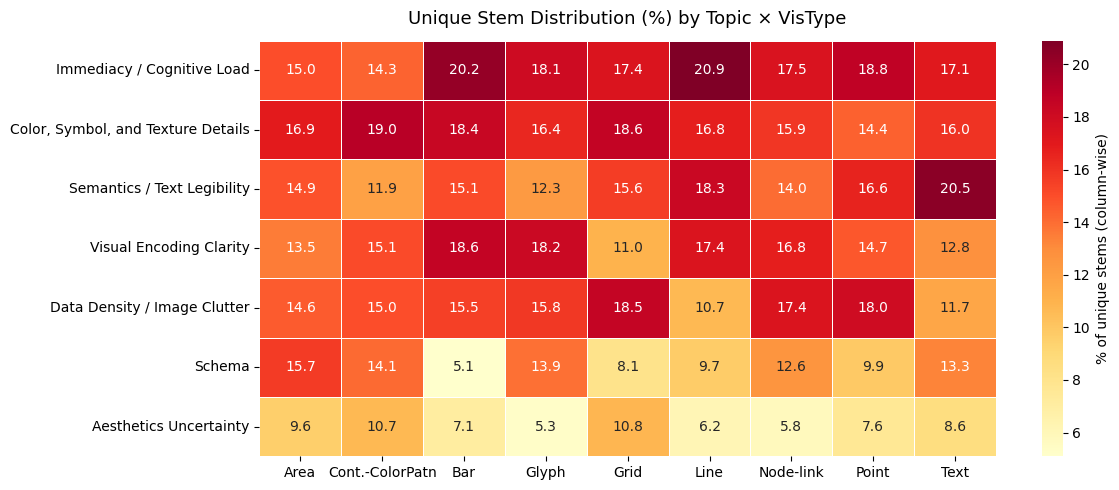

In [18]:
# ── Heatmap: stem % by Topic × VisType (sorted descending on both axes) ──────────
import matplotlib.pyplot as plt
import seaborn as sns

# Sort rows by mean % descending, columns by mean % descending
stem_row_order = df_pivot_pct.mean(axis=1).sort_values(ascending=False).index
stem_col_order = df_pivot_pct.mean(axis=0).sort_values(ascending=False).index
df_stem_sorted = df_pivot_pct.loc[stem_row_order, stem_col_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    df_stem_sorted,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of unique stems (column-wise)'},
    ax=ax,
)
ax.set_title('Unique Stem Distribution (%) by Topic × VisType', fontsize=13, pad=12)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Pivot: image counts by Topic × VisType

In [76]:
# For each (VisType, Topic) pair, count unique images.
# An image counts for a (VisType, Topic) pair if it has that VisType and that Topic.

vt_topic_images = defaultdict(lambda: defaultdict(set))  # vt → topic → {imageNames}

for _, row in df_out.iterrows():
    vt = row['VisType']
    topics_str = row['Topics']
    img = row['imageName']

    if not isinstance(vt, str) or not vt.strip():
        continue

    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []
    for topic in topics:
        vt_topic_images[vt.strip()][topic].add(img)

# Build counts table
img_pivot_rows = []
for topic in topic_names:
    row_data = {'Topic': topic}
    for vt in vistype_names:
        row_data[vt] = len(vt_topic_images[vt].get(topic, set()))
    img_pivot_rows.append(row_data)

df_img_pivot_counts = pd.DataFrame(img_pivot_rows).set_index('Topic')

# Total images per VisType (for column headers and pct calculation)
vt_total_images = {vt: df_out[df_out['VisType'] == vt]['imageName'].nunique() for vt in vistype_names}

# Rename count columns to include total image count
df_img_pivot_counts.columns = [f'{vt} ({vt_total_images[vt]})' for vt in vistype_names]
df_img_pivot_counts.to_csv('phrase_reduction_v2/image_pivot_topic_vistype_counts.csv')

print('Image counts by Topic × VisType')
display(df_img_pivot_counts)

# Percentages: topic-vistype images / total vistype images
df_img_pivot_pct = df_img_pivot_counts.copy()
for vt in vistype_names:
    col = f'{vt} ({vt_total_images[vt]})'
    total = vt_total_images[vt]
    df_img_pivot_pct[col] = (df_img_pivot_counts[col] / total * 100).round(1) if total > 0 else 0.0
df_img_pivot_pct.to_csv('phrase_reduction_v2/image_pivot_topic_vistype_pct.csv')

print('\nImage distribution (%) by Topic × VisType')
print('Saved: phrase_reduction_v2/image_pivot_topic_vistype_counts.csv')
print('Saved: phrase_reduction_v2/image_pivot_topic_vistype_pct.csv')
df_img_pivot_pct

Image counts by Topic × VisType


,Area (65),Bar (51),Cont.-ColorPatn (42),Glyph (64),Grid (65),Line (48),Node-link (66),Point (58),Text (51)
Topic,,,,,,,,,
Data Density / Image Clutter,24,17,16,22,39,14,32,29,17
Visual Encoding Clarity,12,12,10,21,9,21,22,17,11
Semantics / Text Legibility,25,15,9,15,21,17,22,26,30
Schema,28,9,14,25,13,16,23,21,14
"Color, Symbol, and Texture Details",34,18,27,26,40,15,29,22,17
Aesthetics Uncertainty,8,3,8,11,9,5,6,7,6
Immediacy / Cognitive Load,35,35,20,34,29,27,41,29,27



Image distribution (%) by Topic × VisType
Saved: phrase_reduction_v2/image_pivot_topic_vistype_counts.csv
Saved: phrase_reduction_v2/image_pivot_topic_vistype_pct.csv


,Area (65),Bar (51),Cont.-ColorPatn (42),Glyph (64),Grid (65),Line (48),Node-link (66),Point (58),Text (51)
Topic,,,,,,,,,
Data Density / Image Clutter,36.9,33.3,38.1,34.4,60.0,29.2,48.5,50.0,33.3
Visual Encoding Clarity,18.5,23.5,23.8,32.8,13.8,43.8,33.3,29.3,21.6
Semantics / Text Legibility,38.5,29.4,21.4,23.4,32.3,35.4,33.3,44.8,58.8
Schema,43.1,17.6,33.3,39.1,20.0,33.3,34.8,36.2,27.5
"Color, Symbol, and Texture Details",52.3,35.3,64.3,40.6,61.5,31.2,43.9,37.9,33.3
Aesthetics Uncertainty,12.3,5.9,19.0,17.2,13.8,10.4,9.1,12.1,11.8
Immediacy / Cognitive Load,53.8,68.6,47.6,53.1,44.6,56.2,62.1,50.0,52.9


In [86]:
# ── Same image pivot but filtered to images with NormalizedVC > 0.5 ───────────
df_hvc = df_out[df_out['NormalizedVC'] > 0.5].copy()
print(f'Images with NormalizedVC > 0.5: {len(df_hvc)}/{len(df_out)}')

vt_topic_images_hvc = defaultdict(lambda: defaultdict(set))
for _, row in df_hvc.iterrows():
    vt = row['VisType']
    topics_str = row['Topics']
    img = row['imageName']
    if not isinstance(vt, str) or not vt.strip():
        continue
    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []
    for topic in topics:
        vt_topic_images_hvc[vt.strip()][topic].add(img)

img_pivot_rows_hvc = []
for topic in topic_names:
    row_data = {'Topic': topic}
    for vt in vistype_names:
        row_data[vt] = len(vt_topic_images_hvc[vt].get(topic, set()))
    img_pivot_rows_hvc.append(row_data)

df_img_pivot_counts_hvc = pd.DataFrame(img_pivot_rows_hvc).set_index('Topic')
vt_total_hvc = {vt: df_hvc[df_hvc['VisType'] == vt]['imageName'].nunique() for vt in vistype_names}
df_img_pivot_counts_hvc.columns = [f'{vt} ({vt_total_hvc[vt]})' for vt in vistype_names]
df_img_pivot_counts_hvc.to_csv('phrase_reduction_v2/image_pivot_topic_vistype_counts_hvc.csv')

print('Image counts by Topic × VisType (NormalizedVC > 0.5)')
display(df_img_pivot_counts_hvc)

df_img_pivot_pct_hvc = df_img_pivot_counts_hvc.copy()
for vt in vistype_names:
    col = f'{vt} ({vt_total_hvc[vt]})'
    total = vt_total_hvc[vt]
    df_img_pivot_pct_hvc[col] = (df_img_pivot_counts_hvc[col] / total * 100).round(1) if total > 0 else 0.0
df_img_pivot_pct_hvc.to_csv('phrase_reduction_v2/image_pivot_topic_vistype_pct_hvc.csv')

print('\nImage distribution (%) by Topic × VisType (NormalizedVC > 0.5)')
print('Saved: phrase_reduction_v2/image_pivot_topic_vistype_counts_hvc.csv')
print('Saved: phrase_reduction_v2/image_pivot_topic_vistype_pct_hvc.csv')
df_img_pivot_pct_hvc

Images with NormalizedVC > 0.5: 388/520
Image counts by Topic × VisType (NormalizedVC > 0.5)


,Area (51),Bar (22),Cont.-ColorPatn (38),Glyph (57),Grid (57),Line (22),Node-link (54),Point (45),Text (38)
Topic,,,,,,,,,
Data Density / Image Clutter,20,7,14,21,36,9,30,23,11
Visual Encoding Clarity,9,8,10,19,8,12,15,14,8
Semantics / Text Legibility,19,5,8,13,20,8,18,21,24
Schema,23,1,13,22,11,6,19,16,10
"Color, Symbol, and Texture Details",26,8,24,21,35,9,25,16,12
Aesthetics Uncertainty,6,3,8,10,8,3,5,4,4
Immediacy / Cognitive Load,26,15,19,28,26,10,34,22,20



Image distribution (%) by Topic × VisType (NormalizedVC > 0.5)
Saved: phrase_reduction_v2/image_pivot_topic_vistype_counts_hvc.csv
Saved: phrase_reduction_v2/image_pivot_topic_vistype_pct_hvc.csv


,Area (51),Bar (22),Cont.-ColorPatn (38),Glyph (57),Grid (57),Line (22),Node-link (54),Point (45),Text (38)
Topic,,,,,,,,,
Data Density / Image Clutter,39.2,31.8,36.8,36.8,63.2,40.9,55.6,51.1,28.9
Visual Encoding Clarity,17.6,36.4,26.3,33.3,14.0,54.5,27.8,31.1,21.1
Semantics / Text Legibility,37.3,22.7,21.1,22.8,35.1,36.4,33.3,46.7,63.2
Schema,45.1,4.5,34.2,38.6,19.3,27.3,35.2,35.6,26.3
"Color, Symbol, and Texture Details",51.0,36.4,63.2,36.8,61.4,40.9,46.3,35.6,31.6
Aesthetics Uncertainty,11.8,13.6,21.1,17.5,14.0,13.6,9.3,8.9,10.5
Immediacy / Cognitive Load,51.0,68.2,50.0,49.1,45.6,45.5,63.0,48.9,52.6


In [77]:
# ── Topic × VisType sentiment pivot (self-contained) ─────────────────────────
# Builds topic-level sentiment from scratch using cell 2 globals
# (df_compiled, df_term, df_shortlist, vistype_names)

# Colorblind-safe Okabe-Ito palette
COLOR_NEG = '#009E73'   # bluish green — easy to understand
COLOR_MIX = '#F0E442'   # yellow — mixed
COLOR_POS = '#D55E00'   # vermillion — hard to understand

# Load taxonomy → subtopic_to_topic mapping
_df_tax = pd.read_csv('phrase_reduction_v2/subtopic_taxonomy.csv')
_subtopic_to_topic = {}
_subtopic_order = []
for _, tr in _df_tax.iterrows():
    _subtopic_to_topic[tr['subtopic']] = tr['topic']
    _subtopic_order.append((tr['topic'], tr['subtopic']))

# Load image-phrase mapping
_df_mapping = pd.read_csv('phrase_reduction_v2/image_phrase_word_mapping.csv')

# Build phrase → subtopic mapping (taxonomy + shortlist)
_hc_to_subtopic = {}
for _, tr in _df_tax.iterrows():
    for p in str(tr['phrases']).split(';'):
        p = p.strip()
        if p:
            _hc_to_subtopic[p] = tr['subtopic']
for _, row in df_shortlist.iterrows():
    for p in str(row['Phrases']).split('\n'):
        p = p.strip()
        if p:
            _hc_to_subtopic[p] = row['SubTopic']

# HumanCurated phrase → sentiment sign
_hc_to_sign = {}
for _, row in df_term.iterrows():
    hc = row.get('HumanCurated')
    sign = row.get('HumanCuratedSign')
    if isinstance(hc, str) and isinstance(sign, str):
        _hc_to_sign[hc.strip()] = sign.strip()

# Image-level fallback sentiment
_img_fallback = {}
for _, row in df_compiled.iterrows():
    os_str = row.get('originalSentiments', '')
    if not isinstance(os_str, str):
        continue
    signals = set()
    if '(+)' in os_str or '(+/-)' in os_str or '(+) (-)' in os_str:
        signals.add('+')
    if '(-)' in os_str or '(+/-)' in os_str or '(+) (-)' in os_str:
        signals.add('-')
    if signals:
        _img_fallback[row['imageName']] = signals

# ── Image-level sentiment ────────────────────────────────────────────────────
# Collect ALL phrase signs per image (not per subtopic)
_img_signs = defaultdict(set)
for _, row in _df_mapping.iterrows():
    img = row['imageName']
    hc_str = row.get('humanCuratedPhrases', '')
    if not isinstance(hc_str, str):
        continue
    for phrase in hc_str.split(';'):
        phrase = phrase.strip()
        if not phrase:
            continue
        sign = _hc_to_sign.get(phrase, '')
        if not sign:
            continue
        if '(+/-)' in sign:
            _img_signs[img].update(['+', '-'])
        else:
            if '(+)' in sign:
                _img_signs[img].add('+')
            if '(-)' in sign:
                _img_signs[img].add('-')

# Fill in from image-level fallback for images with no phrase-level signs
for img, fb in _img_fallback.items():
    if img not in _img_signs:
        _img_signs[img] = fb.copy()

# Resolve to single sentiment label per image
_img_sentiment = {}
for img, signals in _img_signs.items():
    if '+' in signals and '-' in signals:
        _img_sentiment[img] = '(+/-)'
    elif '-' in signals:
        _img_sentiment[img] = '(-)'
    else:
        _img_sentiment[img] = '(+)'

# Build unique (image, topic, vistype) records with image-level sentiment
topic_sent_records = []
_seen_itv = set()
for _, row in _df_mapping.iterrows():
    img = row['imageName']
    vt = str(row.get('VisType', '')).strip()
    if vt not in vistype_names:
        continue
    st_str = row.get('SubTopics', '')
    if not isinstance(st_str, str) or not st_str.strip():
        continue
    for st in st_str.split(';'):
        st = st.strip()
        topic = _subtopic_to_topic.get(st)
        if not topic:
            continue
        key = (img, topic, vt)
        if key in _seen_itv:
            continue
        _seen_itv.add(key)
        topic_sent_records.append({
            'imageName': img, 'Topic': topic, 'VisType': vt,
            'sentiment': _img_sentiment.get(img, '(+)')
        })

df_sent_topic_flat = pd.DataFrame(topic_sent_records)
print(f'Topic-level sentiment records: {len(df_sent_topic_flat)}')
print(f'Sentiment distribution:\n{df_sent_topic_flat["sentiment"].value_counts().to_string()}')

# Ordered topic list
topic_names_ordered = list(dict.fromkeys(t for t, _ in _subtopic_order))

# Build pivot: Topic × VisType with sentiment subcategories
sent_cats = ['(+)', '(-)', '(+/-)']
topic_pivot_rows = []
for topic in topic_names_ordered:
    row_data = {'Topic': topic}
    total = {sc: 0 for sc in sent_cats}
    for vt in vistype_names:
        for sc in sent_cats:
            mask = ((df_sent_topic_flat['Topic'] == topic) &
                    (df_sent_topic_flat['VisType'] == vt) &
                    (df_sent_topic_flat['sentiment'] == sc))
            count = df_sent_topic_flat[mask]['imageName'].nunique()
            row_data[f'{vt} {sc}'] = count
            total[sc] += count
    for sc in sent_cats:
        row_data[f'Total {sc}'] = total[sc]
    topic_pivot_rows.append(row_data)

df_topic_sent_pivot = pd.DataFrame(topic_pivot_rows).set_index('Topic')

# Sort by total mentions descending
all_topic_cols = [f'{vt} {sc}' for vt in vistype_names for sc in sent_cats]
df_topic_sent_pivot['_total'] = df_topic_sent_pivot[all_topic_cols].sum(axis=1)
df_topic_sent_pivot = df_topic_sent_pivot.sort_values('_total', ascending=False).drop(columns='_total')

csv_path = 'phrase_reduction_v2/topic_vistype_sentiment.csv'
df_topic_sent_pivot.to_csv(csv_path)
print(f'\nTopic × VisType sentiment breakdown ({len(df_topic_sent_pivot)} topics)')
display(df_topic_sent_pivot)
print(f'Saved: {csv_path}')

Topic-level sentiment records: 1256
Sentiment distribution:
sentiment
(+/-)    1146
(+)        94
(-)        16

Topic × VisType sentiment breakdown (7 topics)


,Area (+),Area (-),Area (+/-),Bar (+),Bar (-),Bar (+/-),Cont.-ColorPatn (+),Cont.-ColorPatn (-),Cont.-ColorPatn (+/-),Glyph (+),...,Node-link (+/-),Point (+),Point (-),Point (+/-),Text (+),Text (-),Text (+/-),Total (+),Total (-),Total (+/-)
Topic,,,,,,,,,,,,,,,,,,,,,
Immediacy / Cognitive Load,4,3,28,5,3,27,2,0,18,5,...,30,4,0,25,3,0,24,38,12,227
"Color, Symbol, and Texture Details",1,0,33,1,0,17,2,0,25,0,...,29,2,0,20,0,0,17,9,0,219
Data Density / Image Clutter,1,0,23,0,0,17,0,0,16,1,...,30,2,0,27,1,0,16,13,0,197
Semantics / Text Legibility,0,0,25,1,0,14,0,0,9,0,...,21,1,1,24,1,0,29,5,1,174
Schema,1,0,27,1,0,8,0,0,14,4,...,20,3,0,18,0,1,13,13,1,149
Visual Encoding Clarity,0,0,12,1,0,11,0,0,10,0,...,20,3,0,14,0,0,11,9,1,125
Aesthetics Uncertainty,0,0,8,0,0,3,2,0,6,0,...,6,2,1,4,1,0,5,7,1,55


Saved: phrase_reduction_v2/topic_vistype_sentiment.csv


In [87]:
# ── Topic × VisType sentiment pivot (NormalizedVC > 0.5) ─────────────────────
# Same image-level sentiment logic as above, restricted to high-VC images.

_hvc_imgs = set(df_out.loc[df_out['NormalizedVC'] > 0.5, 'imageName'])
_df_mapping_hvc = _df_mapping[_df_mapping['imageName'].isin(_hvc_imgs)]
print(f'High-VC images in mapping: {_df_mapping_hvc["imageName"].nunique()}/{_df_mapping["imageName"].nunique()}')

# Build unique (image, topic, vistype) records with image-level sentiment (high-VC only)
topic_sent_records_hvc = []
_seen_itv_hvc = set()
for _, row in _df_mapping_hvc.iterrows():
    img = row['imageName']
    vt = str(row.get('VisType', '')).strip()
    if vt not in vistype_names:
        continue
    st_str = row.get('SubTopics', '')
    if not isinstance(st_str, str) or not st_str.strip():
        continue
    for st in st_str.split(';'):
        st = st.strip()
        topic = _subtopic_to_topic.get(st)
        if not topic:
            continue
        key = (img, topic, vt)
        if key in _seen_itv_hvc:
            continue
        _seen_itv_hvc.add(key)
        topic_sent_records_hvc.append({
            'imageName': img, 'Topic': topic, 'VisType': vt,
            'sentiment': _img_sentiment.get(img, '(+)')
        })

df_sent_topic_flat_hvc = pd.DataFrame(topic_sent_records_hvc)
print(f'Topic-level sentiment records (VC > 0.5): {len(df_sent_topic_flat_hvc)}')
print(f'Sentiment distribution:\n{df_sent_topic_flat_hvc["sentiment"].value_counts().to_string()}')

# Build pivot
topic_pivot_rows_hvc = []
for topic in topic_names_ordered:
    row_data = {'Topic': topic}
    total = {sc: 0 for sc in sent_cats}
    for vt in vistype_names:
        for sc in sent_cats:
            mask = ((df_sent_topic_flat_hvc['Topic'] == topic) &
                    (df_sent_topic_flat_hvc['VisType'] == vt) &
                    (df_sent_topic_flat_hvc['sentiment'] == sc))
            count = df_sent_topic_flat_hvc[mask]['imageName'].nunique()
            row_data[f'{vt} {sc}'] = count
            total[sc] += count
    for sc in sent_cats:
        row_data[f'Total {sc}'] = total[sc]
    topic_pivot_rows_hvc.append(row_data)

df_topic_sent_pivot_hvc = pd.DataFrame(topic_pivot_rows_hvc).set_index('Topic')

# Sort by total mentions descending
df_topic_sent_pivot_hvc['_total'] = df_topic_sent_pivot_hvc[all_topic_cols].sum(axis=1)
df_topic_sent_pivot_hvc = df_topic_sent_pivot_hvc.sort_values('_total', ascending=False).drop(columns='_total')

csv_path_hvc = 'phrase_reduction_v2/topic_vistype_sentiment_hvc.csv'
df_topic_sent_pivot_hvc.to_csv(csv_path_hvc)
print(f'\nTopic × VisType sentiment breakdown – NormalizedVC > 0.5 ({len(df_topic_sent_pivot_hvc)} topics)')
display(df_topic_sent_pivot_hvc)
print(f'Saved: {csv_path_hvc}')

High-VC images in mapping: 388/520
Topic-level sentiment records (VC > 0.5): 958
Sentiment distribution:
sentiment
(+/-)    867
(+)       80
(-)       11

Topic × VisType sentiment breakdown – NormalizedVC > 0.5 (7 topics)


,Area (+),Area (-),Area (+/-),Bar (+),Bar (-),Bar (+/-),Cont.-ColorPatn (+),Cont.-ColorPatn (-),Cont.-ColorPatn (+/-),Glyph (+),...,Node-link (+/-),Point (+),Point (-),Point (+/-),Text (+),Text (-),Text (+/-),Total (+),Total (-),Total (+/-)
Topic,,,,,,,,,,,,,,,,,,,,,
Immediacy / Cognitive Load,3,2,21,5,1,9,1,0,18,5,...,24,4,0,18,2,0,18,32,8,160
"Color, Symbol, and Texture Details",1,0,25,1,0,7,2,0,22,0,...,25,1,0,15,0,0,12,7,0,169
Data Density / Image Clutter,1,0,19,0,0,7,0,0,14,1,...,28,2,0,21,1,0,10,13,0,158
Semantics / Text Legibility,0,0,19,0,0,5,0,0,8,0,...,17,1,1,19,1,0,23,4,1,131
Schema,1,0,22,0,0,1,0,0,13,4,...,17,3,0,13,0,1,9,11,1,109
Visual Encoding Clarity,0,0,9,1,0,7,0,0,10,0,...,14,3,0,11,0,0,8,7,0,96
Aesthetics Uncertainty,0,0,6,0,0,3,2,0,6,0,...,5,1,1,2,1,0,3,6,1,44


Saved: phrase_reduction_v2/topic_vistype_sentiment_hvc.csv


In [79]:
# # ── Proportional diverging bar chart: Topic sentiment (ALL VisTypes) ──────────
# # Each bar is normalized to 100% of (pos + neg + mix) for that topic

# plot_topic = df_topic_sent_pivot[['Total (+)', 'Total (-)', 'Total (+/-)']].copy()
# totals = plot_topic['Total (+)'] + plot_topic['Total (-)'] + plot_topic['Total (+/-)']
# totals = totals.replace(0, 1)

# plot_topic['pct_pos'] = (plot_topic['Total (+)'] / totals * 100).round(1)
# plot_topic['pct_neg'] = (plot_topic['Total (-)'] / totals * 100).round(1)
# plot_topic['pct_mix'] = (plot_topic['Total (+/-)'] / totals * 100).round(1)
# plot_topic = plot_topic.sort_values('pct_pos', ascending=True)

# topics = plot_topic.index.tolist()
# pos_pct = plot_topic['pct_pos'].values
# neg_pct = plot_topic['pct_neg'].values
# mix_pct = plot_topic['pct_mix'].values

# y = np.arange(len(topics))
# bar_height = 0.6

# fig, ax = plt.subplots(figsize=(12, 5))

# ax.barh(y, neg_pct, height=bar_height, left=-neg_pct, color=COLOR_NEG, label='(−) easy', zorder=2)
# ax.barh(y, mix_pct, height=bar_height, left=-mix_pct / 2, color=COLOR_MIX, label='(+/−) mixed', zorder=3)
# ax.barh(y, pos_pct, height=bar_height, left=0, color=COLOR_POS, label='(+) hard', zorder=2)

# for i in range(len(topics)):
#     half_mix = mix_pct[i] / 2
#     if neg_pct[i] > 3:
#         label_x = -(half_mix + neg_pct[i]) / 2 if neg_pct[i] > half_mix else -neg_pct[i] / 2
#         ax.text(label_x, i, f'{neg_pct[i]:.0f}%', ha='center', va='center',
#                 fontsize=9, fontweight='bold', color='white')
#     if mix_pct[i] > 3:
#         ax.text(0, i, f'{mix_pct[i]:.0f}%', ha='center', va='center',
#                 fontsize=9, fontweight='bold', color='black')
#     if pos_pct[i] > 3:
#         label_x = (half_mix + pos_pct[i]) / 2 if pos_pct[i] > half_mix else pos_pct[i] / 2
#         ax.text(label_x, i, f'{pos_pct[i]:.0f}%', ha='center', va='center',
#                 fontsize=9, fontweight='bold', color='white')

# ax.set_yticks(y)
# ax.set_yticklabels(topics, fontsize=10)
# ax.set_xlabel('Proportion (%)', fontsize=11)
# ax.set_title('Topic Sentiment Proportion (Diverging)', fontsize=13, fontweight='bold')
# ax.axvline(0, color='black', linewidth=0.8, zorder=4)
# ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
# ax.grid(axis='x', alpha=0.3, zorder=0)

# plt.tight_layout()
# plt.savefig('phrase_reduction_v2/topic_sentiment_proportion.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved: phrase_reduction_v2/topic_sentiment_proportion.png')

### Pivot: image counts by SubTopic × VisType

In [80]:
# Build subtopic → topic lookup from subtopic_taxonomy.csv
df_taxonomy = pd.read_csv('phrase_reduction_v2/subtopic_taxonomy.csv')
subtopic_to_topic = {}   # subtopic_name → topic
subtopic_order = []      # ordered list of (topic, subtopic)
phrase_to_subtopic = {}  # phrase → (topic, subtopic_name)
for _, tr in df_taxonomy.iterrows():
    topic = tr['topic']
    st = tr['subtopic']
    subtopic_order.append((topic, st))
    subtopic_to_topic[st] = topic
    for p in str(tr['phrases']).split(';'):
        p = p.strip()
        if p:
            phrase_to_subtopic[p] = (topic, st)

subtopic_names = [st for _, st in subtopic_order]
print(f'Taxonomy: {len(subtopic_names)} subtopics, {len(phrase_to_subtopic)} phrases')

# Use pre-mapped SubTopics from image_phrase_word_mapping.csv (subtopic names, not raw phrases)
df_mapping = pd.read_csv('phrase_reduction_v2/image_phrase_word_mapping.csv')

# Count unique images per (SubTopic, VisType)
vt_subtopic_images = defaultdict(lambda: defaultdict(set))  # vt → subtopic → {imageNames}

for _, row in df_mapping.iterrows():
    vt = row['VisType']
    st_str = row['SubTopics']
    img = row['imageName']

    if not isinstance(vt, str) or not vt.strip():
        continue
    if vt.strip() not in vistype_names:
        continue
    if not isinstance(st_str, str) or not st_str.strip():
        continue

    for st in st_str.split(';'):
        st = st.strip()
        if st in subtopic_to_topic:
            vt_subtopic_images[vt.strip()][st].add(img)

# Build counts table (rows = subtopics in taxonomy order)
st_pivot_rows = []
for topic, st in subtopic_order:
    row_data = {'SubTopic': st, 'Topic': topic}
    for vt in vistype_names:
        row_data[vt] = len(vt_subtopic_images[vt].get(st, set()))
    st_pivot_rows.append(row_data)

df_st_pivot_counts = pd.DataFrame(st_pivot_rows).set_index('SubTopic')
# Add Total column and sort by it (descending)
vt_only = [c for c in df_st_pivot_counts.columns if c != 'Topic']
df_st_pivot_counts.insert(1, 'Total', df_st_pivot_counts[vt_only].sum(axis=1))
df_st_pivot_counts = df_st_pivot_counts.sort_values('Total', ascending=False)

# Total images per VisType
vt_total = {vt: df_compiled[df_compiled['VisType'] == vt]['imageName'].nunique() for vt in vistype_names}

# Rename count columns to include total image count
count_cols = {vt: f'{vt} ({vt_total[vt]})' for vt in vistype_names}
df_st_pivot_counts = df_st_pivot_counts.rename(columns=count_cols)
df_st_pivot_counts.to_csv('phrase_reduction_v2/subtopic_vistype_counts.csv')
print(f'SubTopic × VisType image counts ({len(df_st_pivot_counts)} subtopics)')
display(df_st_pivot_counts)

# Percentages: subtopic-vistype images / total vistype images
df_st_pivot_pct = df_st_pivot_counts.copy()
# Rename columns back to plain VisType names for pct table
df_st_pivot_pct = df_st_pivot_pct.rename(columns={v: k for k, v in count_cols.items()})
for vt in vistype_names:
    total = vt_total[vt]
    df_st_pivot_pct[vt] = (df_st_pivot_counts[count_cols[vt]] / total * 100).round(1) if total > 0 else 0.0
df_st_pivot_pct.to_csv('phrase_reduction_v2/subtopic_vistype_pct.csv')


print(f'\nSubTopic × VisType image %')
df_st_pivot_pct

print('Saved: phrase_reduction_v2/subtopic_vistype_counts.csv')
print('Saved: phrase_reduction_v2/subtopic_vistype_pct.csv')

Taxonomy: 19 subtopics, 50 phrases
SubTopic × VisType image counts (19 subtopics)


,Topic,Total,Area (66),Bar (52),Cont.-ColorPatn (42),Glyph (64),Grid (65),Line (48),Node-link (66),Point (58),Text (51)
SubTopic,,,,,,,,,,,
Color Palette & Contrast,"Color, Symbol, and Texture Details",222,34,18,27,24,39,14,27,22,17
Interpretive Difficulty,Immediacy / Cognitive Load,212,28,26,12,24,18,20,37,24,23
Domain Familiarity,Schema,138,25,8,12,19,11,15,18,17,13
Graphical Forms & Primitives,Visual Encoding Clarity,119,11,10,10,20,9,19,18,14,8
Information Volume,Data Density / Image Clutter,117,18,7,8,10,21,8,16,17,12
Element Quantity,Data Density / Image Clutter,113,10,11,11,14,19,8,16,18,6
Annotations & Labels,Semantics / Text Legibility,108,17,10,9,13,12,10,10,18,9
Text Volume & Content,Semantics / Text Legibility,67,7,4,1,2,13,5,13,6,16
Semantic Clarity,Immediacy / Cognitive Load,61,6,5,7,10,6,7,9,5,6



SubTopic × VisType image %
Saved: phrase_reduction_v2/subtopic_vistype_counts.csv
Saved: phrase_reduction_v2/subtopic_vistype_pct.csv


### Pivot: SubTopic × VisType sentiment breakdown

For each (image, subtopic), determine the combined sentiment from the image's original phrases:
- Map each `originalPhrase` → `HumanCurated` (via `term_mapping`) → subtopic (via `phrase_to_subtopic`)
- Carry the per-image `originalSentiment` for each phrase
- Aggregate per (image, subtopic): **(+)** if only positive, **(−)** if only negative, **(+/−)** if both
- Count images per (SubTopic, VisType, sentiment category)

In [81]:
# ── Build comprehensive phrase → subtopic mapping ─────────────────────────────
# Combine taxonomy (semicolon-separated) + shortlist (newline-separated) for max coverage
hc_to_subtopic = {}   # humanCuratedPhrase → subtopic_name
for _, tr in df_taxonomy.iterrows():
    st = tr['subtopic']
    for p in str(tr['phrases']).split(';'):
        p = p.strip()
        if p:
            hc_to_subtopic[p] = st
for _, row in df_shortlist.iterrows():
    st = row['SubTopic']
    for p in str(row['Phrases']).split('\n'):
        p = p.strip()
        if p:
            hc_to_subtopic[p] = st

# HumanCurated phrase → sentiment sign
hc_to_sign = {}
for _, row in df_term.iterrows():
    hc = row.get('HumanCurated')
    sign = row.get('HumanCuratedSign')
    if isinstance(hc, str) and isinstance(sign, str):
        hc_to_sign[hc.strip()] = sign.strip()

print(f'Phrase → subtopic mapping: {len(hc_to_subtopic)} phrases')
print(f'HumanCurated → sign mapping: {len(hc_to_sign)} unique phrases')

# Image-level fallback sentiment (from originalSentiments)
img_fallback = {}
for _, row in df_compiled.iterrows():
    os_str = row.get('originalSentiments', '')
    if not isinstance(os_str, str):
        continue
    signals = set()
    if '(+)' in os_str:
        signals.add('+')
    if '(-)' in os_str:
        signals.add('-')
    if signals:
        img_fallback[row['imageName']] = signals

# ── Image-level sentiment ────────────────────────────────────────────────────
# Collect ALL phrase signs per image (not per subtopic)
_img_signs = defaultdict(set)
for _, row in df_mapping.iterrows():
    img = row['imageName']
    hc_str = row.get('humanCuratedPhrases', '')
    if not isinstance(hc_str, str):
        continue
    for phrase in hc_str.split(';'):
        phrase = phrase.strip()
        if not phrase:
            continue
        sign = hc_to_sign.get(phrase, '')
        if not sign:
            continue
        if '(+/-)' in sign:
            _img_signs[img].update(['+', '-'])
        else:
            if '(+)' in sign:
                _img_signs[img].add('+')
            if '(-)' in sign:
                _img_signs[img].add('-')

# Fill in from image-level fallback for images with no phrase-level signs
for img, fb in img_fallback.items():
    if img not in _img_signs:
        _img_signs[img] = fb.copy()

# Resolve to single sentiment label per image
img_sentiment = {}
for img, signals in _img_signs.items():
    if '+' in signals and '-' in signals:
        img_sentiment[img] = '(+/-)'
    elif '-' in signals:
        img_sentiment[img] = '(-)'
    else:
        img_sentiment[img] = '(+)'

# ── Per (image, subtopic, vistype) — one sentiment per image ──────────────────
sent_records = []
_seen = set()
for _, row in df_mapping.iterrows():
    img = row['imageName']
    vt = str(row.get('VisType', '')).strip()
    if vt not in vistype_names:
        continue
    st_str = row.get('SubTopics', '')
    if not isinstance(st_str, str) or not st_str.strip():
        continue
    for st in st_str.split(';'):
        st = st.strip()
        if st not in subtopic_to_topic:
            continue
        key = (img, st, vt)
        if key in _seen:
            continue
        _seen.add(key)
        sent_records.append({
            'imageName': img, 'VisType': vt, 'SubTopic': st,
            'sentiment': img_sentiment.get(img, '(+)')
        })

df_sent = pd.DataFrame(sent_records)
print(f'Sentiment records: {len(df_sent)} (image, subtopic, VisType) tuples')
print(f'Sentiment distribution:\n{df_sent["sentiment"].value_counts().to_string()}')

# ── Build pivot: SubTopic × VisType with sentiment subcategories ──────────────
sent_cats = ['(+)', '(-)', '(+/-)']

pivot_rows = []
for topic, st in subtopic_order:
    row_data = {'SubTopic': st, 'Topic': topic}
    total = {sc: 0 for sc in sent_cats}
    for vt in vistype_names:
        for sc in sent_cats:
            mask = (df_sent['SubTopic'] == st) & (df_sent['VisType'] == vt) & (df_sent['sentiment'] == sc)
            count = df_sent[mask]['imageName'].nunique()
            row_data[f'{vt} {sc}'] = count
            total[sc] += count
    for sc in sent_cats:
        row_data[f'Total {sc}'] = total[sc]
    pivot_rows.append(row_data)

df_sent_pivot = pd.DataFrame(pivot_rows).set_index('SubTopic')

# Sort by total mentions (sum across all VisTypes and sentiments) descending
all_count_cols = [f'{vt} {sc}' for vt in vistype_names for sc in sent_cats]
df_sent_pivot['_total'] = df_sent_pivot[all_count_cols].sum(axis=1)
df_sent_pivot = df_sent_pivot.sort_values('_total', ascending=False).drop(columns='_total')

csv_path = 'phrase_reduction_v2/subtopic_vistype_sentiment.csv'
df_sent_pivot.to_csv(csv_path)
print(f'\nSubTopic × VisType sentiment breakdown ({len(df_sent_pivot)} subtopics)')
display(df_sent_pivot)
print(f'Saved: {csv_path}')

Phrase → subtopic mapping: 50 phrases
HumanCurated → sign mapping: 400 unique phrases


Sentiment records: 1454 (image, subtopic, VisType) tuples
Sentiment distribution:
sentiment
(+/-)    1340
(+)        98
(-)        16

SubTopic × VisType sentiment breakdown (19 subtopics)


,Topic,Area (+),Area (-),Area (+/-),Bar (+),Bar (-),Bar (+/-),Cont.-ColorPatn (+),Cont.-ColorPatn (-),Cont.-ColorPatn (+/-),...,Node-link (+/-),Point (+),Point (-),Point (+/-),Text (+),Text (-),Text (+/-),Total (+),Total (-),Total (+/-)
SubTopic,,,,,,,,,,,,,,,,,,,,,
Color Palette & Contrast,"Color, Symbol, and Texture Details",1,0,33,1,0,17,2,0,25,...,27,2,0,20,0,0,17,8,0,214
Interpretive Difficulty,Immediacy / Cognitive Load,3,3,22,3,3,20,2,0,10,...,27,4,0,20,3,0,20,28,12,172
Domain Familiarity,Schema,1,0,24,1,0,7,0,0,12,...,16,3,0,14,0,1,12,11,1,126
Graphical Forms & Primitives,Visual Encoding Clarity,0,0,11,1,0,9,0,0,10,...,18,2,0,12,0,0,8,6,1,112
Information Volume,Data Density / Image Clutter,1,0,17,0,0,7,0,0,8,...,16,1,0,16,0,0,12,4,0,113
Element Quantity,Data Density / Image Clutter,0,0,10,0,0,11,0,0,11,...,14,1,0,17,0,0,6,6,0,107
Annotations & Labels,Semantics / Text Legibility,0,0,17,0,0,10,0,0,9,...,10,0,0,18,0,0,9,0,0,108
Text Volume & Content,Semantics / Text Legibility,0,0,7,1,0,3,0,0,1,...,12,0,0,6,1,0,15,4,0,63
Semantic Clarity,Immediacy / Cognitive Load,1,0,5,0,0,5,0,0,7,...,8,0,0,5,0,0,6,4,0,57


Saved: phrase_reduction_v2/subtopic_vistype_sentiment.csv


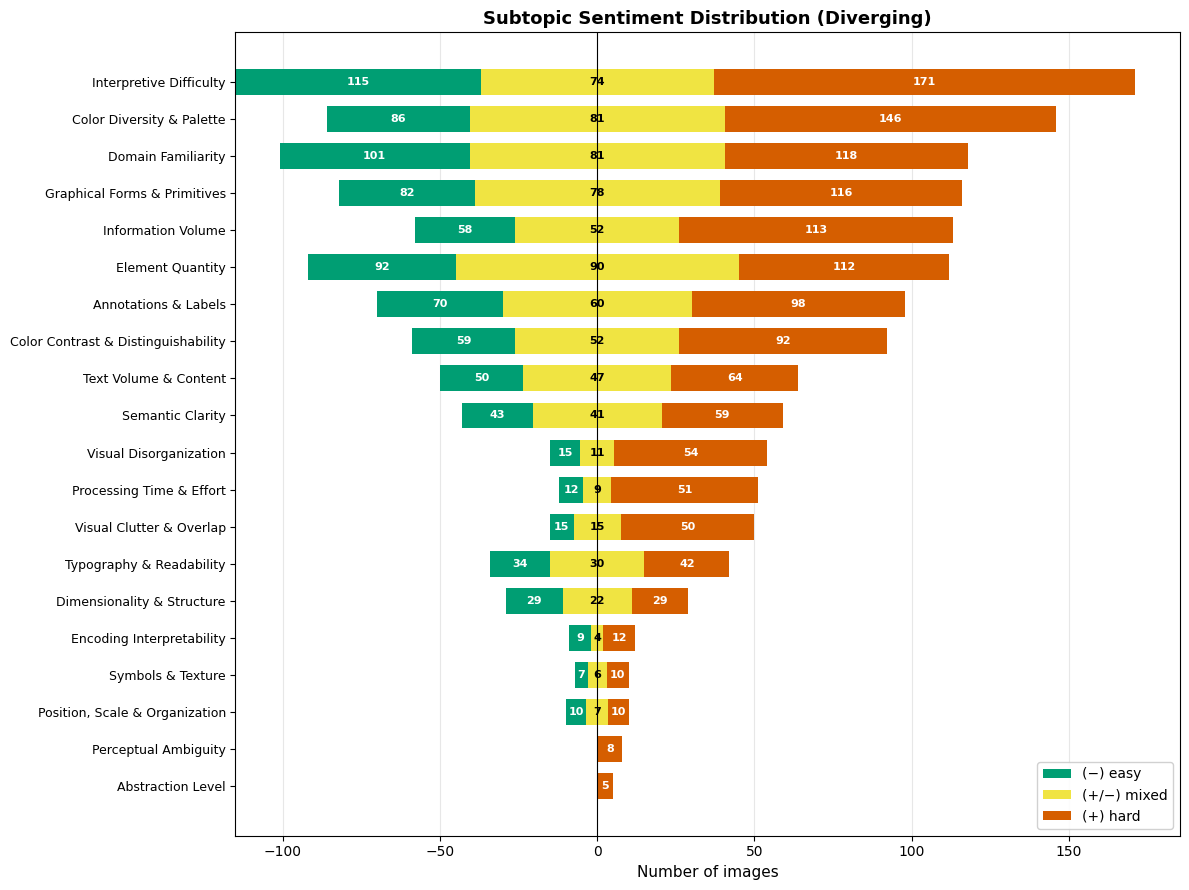

Saved: phrase_reduction_v2/subtopic_sentiment_diverging.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ── Diverging horizontal bar chart: Subtopic sentiment (ALL VisTypes) ─────────
# Left = (-), Center = (+/-), Right = (+)

plot_data = df_sent_pivot[['Topic', 'Total (+)', 'Total (-)', 'Total (+/-)']].copy()
plot_data = plot_data.sort_values('Total (+)', ascending=True)

subtopics = plot_data.index.tolist()
pos_vals = plot_data['Total (+)'].values
neg_vals = plot_data['Total (-)'].values
mix_vals = plot_data['Total (+/-)'].values

y = np.arange(len(subtopics))
bar_height = 0.7

fig, ax = plt.subplots(figsize=(12, 9))

# Colorblind-safe (Okabe-Ito): (-) easy=bluish-green, (+) hard=vermillion, (+/-) mixed=yellow
COLOR_NEG = '#009E73'   # bluish green — easy to understand
COLOR_MIX = '#F0E442'   # yellow — mixed
COLOR_POS = '#D55E00'   # vermillion — hard to understand

ax.barh(y, neg_vals, height=bar_height, left=-neg_vals, color=COLOR_NEG, label='(−) easy', zorder=2)
ax.barh(y, mix_vals, height=bar_height, left=-mix_vals / 2, color=COLOR_MIX, label='(+/−) mixed', zorder=3)
ax.barh(y, pos_vals, height=bar_height, left=0, color=COLOR_POS, label='(+) hard', zorder=2)

for i in range(len(subtopics)):
    half_mix = mix_vals[i] / 2
    if neg_vals[i] > 0:
        label_x = -(half_mix + neg_vals[i]) / 2 if neg_vals[i] > half_mix else -neg_vals[i] / 2
        ax.text(label_x, i, str(neg_vals[i]), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    if mix_vals[i] > 0:
        ax.text(0, i, str(mix_vals[i]), ha='center', va='center',
                fontsize=8, fontweight='bold', color='black')
    if pos_vals[i] > 0:
        label_x = (half_mix + pos_vals[i]) / 2 if pos_vals[i] > half_mix else pos_vals[i] / 2
        ax.text(label_x, i, str(pos_vals[i]), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

ax.set_yticks(y)
ax.set_yticklabels(subtopics, fontsize=9)
ax.set_xlabel('Number of images', fontsize=11)
ax.set_title('Subtopic Sentiment Distribution (Diverging)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, zorder=3)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='x', alpha=0.3, zorder=0)

plt.tight_layout()

plt.savefig('phrase_reduction_v2/subtopic_sentiment_diverging.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phrase_reduction_v2/subtopic_sentiment_diverging.png')

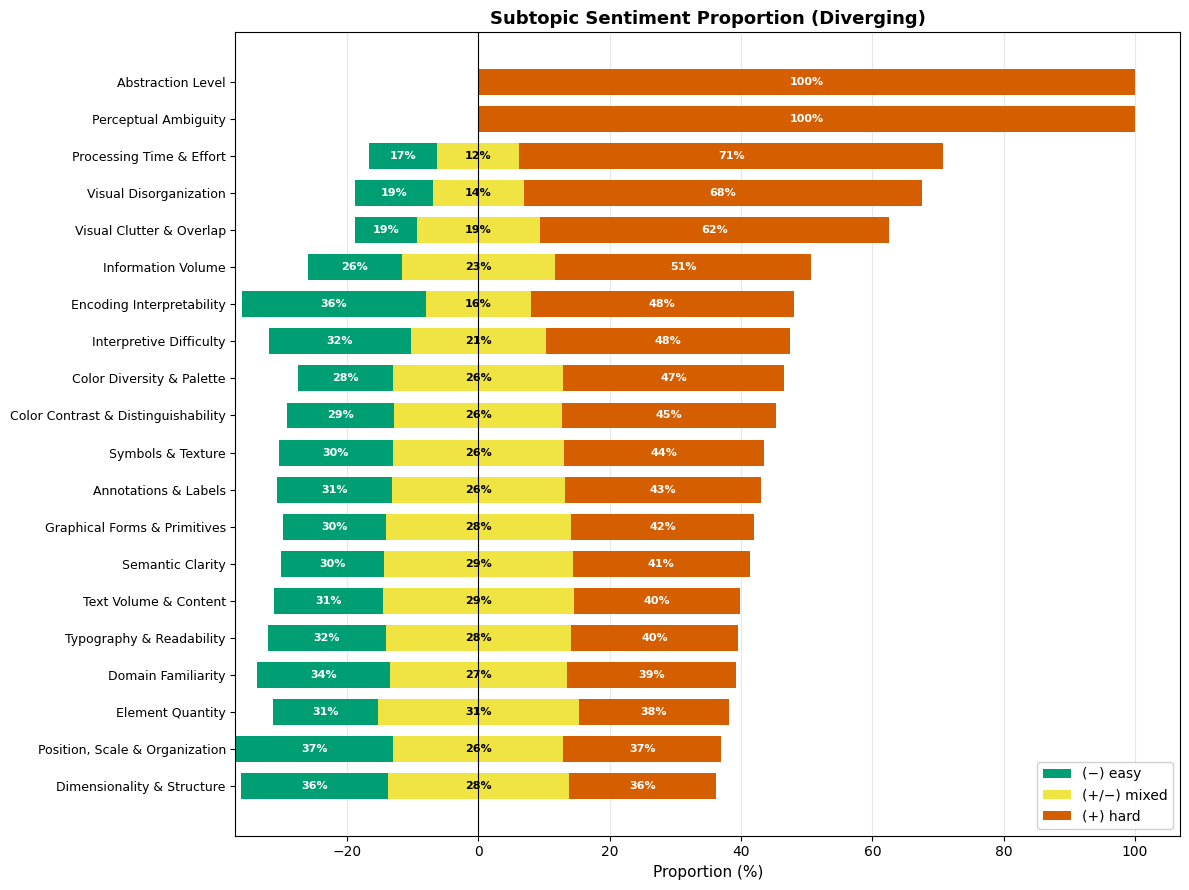

Saved: phrase_reduction_v2/subtopic_sentiment_proportion.png


In [29]:
# ── Proportional diverging bar chart: Subtopic sentiment (ALL VisTypes) ───────
# Each bar is normalized to 100% of (pos + neg + mix) for that subtopic

plot_data = df_sent_pivot[['Topic', 'Total (+)', 'Total (-)', 'Total (+/-)']].copy()
totals = plot_data['Total (+)'] + plot_data['Total (-)'] + plot_data['Total (+/-)']
totals = totals.replace(0, 1)  # avoid division by zero

plot_data['pct_pos'] = (plot_data['Total (+)'] / totals * 100).round(1)
plot_data['pct_neg'] = (plot_data['Total (-)'] / totals * 100).round(1)
plot_data['pct_mix'] = (plot_data['Total (+/-)'] / totals * 100).round(1)
plot_data = plot_data.sort_values('pct_pos', ascending=True)

subtopics = plot_data.index.tolist()
pos_pct = plot_data['pct_pos'].values
neg_pct = plot_data['pct_neg'].values
mix_pct = plot_data['pct_mix'].values

y = np.arange(len(subtopics))
bar_height = 0.7

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(y, neg_pct, height=bar_height, left=-neg_pct, color=COLOR_NEG, label='(−) easy', zorder=2)
ax.barh(y, mix_pct, height=bar_height, left=-mix_pct / 2, color=COLOR_MIX, label='(+/−) mixed', zorder=3)
ax.barh(y, pos_pct, height=bar_height, left=0, color=COLOR_POS, label='(+) hard', zorder=2)

for i in range(len(subtopics)):
    half_mix = mix_pct[i] / 2
    if neg_pct[i] > 3:
        label_x = -(half_mix + neg_pct[i]) / 2 if neg_pct[i] > half_mix else -neg_pct[i] / 2
        ax.text(label_x, i, f'{neg_pct[i]:.0f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    if mix_pct[i] > 3:
        ax.text(0, i, f'{mix_pct[i]:.0f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color='black')
    if pos_pct[i] > 3:
        label_x = (half_mix + pos_pct[i]) / 2 if pos_pct[i] > half_mix else pos_pct[i] / 2
        ax.text(label_x, i, f'{pos_pct[i]:.0f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

ax.set_yticks(y)
ax.set_yticklabels(subtopics, fontsize=9)
ax.set_xlabel('Proportion (%)', fontsize=11)
ax.set_title('Subtopic Sentiment Proportion (Diverging)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, zorder=4)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='x', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('phrase_reduction_v2/subtopic_sentiment_proportion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phrase_reduction_v2/subtopic_sentiment_proportion.png')

Saved: phrase_reduction_v2/subtopic_sentiment_per_vistype.png


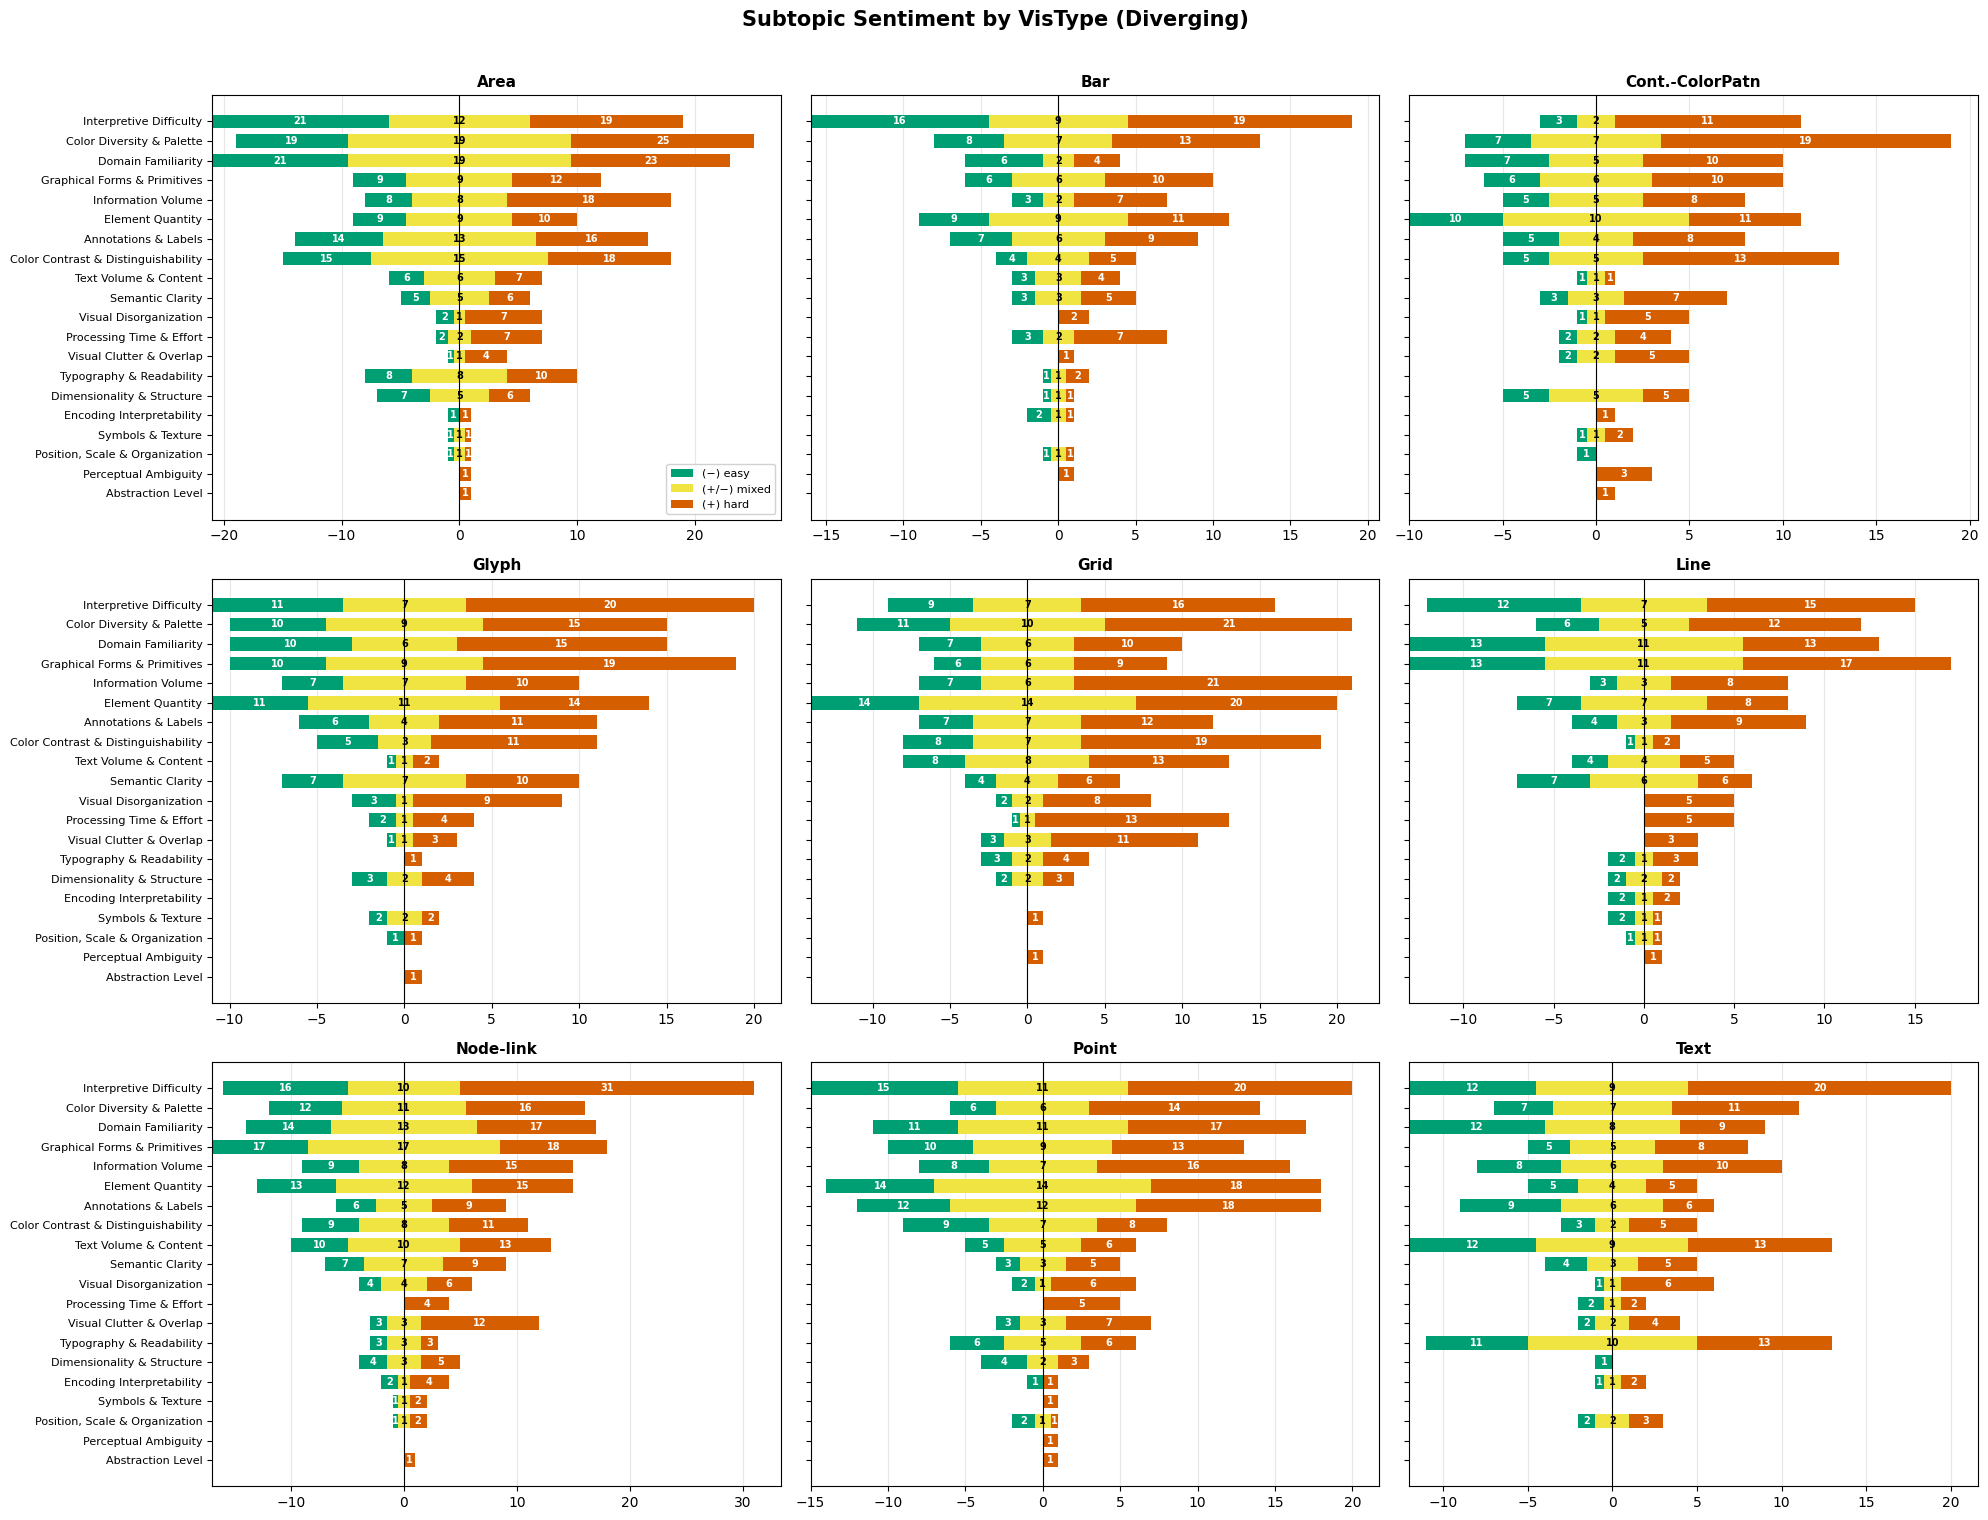

In [31]:
# ── Diverging horizontal bar charts: Subtopic sentiment per VisType (3×3) ─────
n_vt = len(vistype_names)
ncols = 3
nrows = (n_vt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), sharey=True)
axes = axes.flatten()

# Consistent subtopic order (sorted by total (+) across all VisTypes)
sort_key = df_sent_pivot[[f'{vt} (+)' for vt in vistype_names]].sum(axis=1)
sorted_subtopics = sort_key.sort_values(ascending=True).index.tolist()
y = np.arange(len(sorted_subtopics))
bar_height = 0.7

for idx, vt in enumerate(vistype_names):
    ax = axes[idx]
    pos_vals = df_sent_pivot.loc[sorted_subtopics, f'{vt} (+)'].values
    neg_vals = df_sent_pivot.loc[sorted_subtopics, f'{vt} (-)'].values
    mix_vals = df_sent_pivot.loc[sorted_subtopics, f'{vt} (+/-)'].values

    ax.barh(y, neg_vals, height=bar_height, left=-neg_vals, color='#009E73', label='(−) easy', zorder=2)
    ax.barh(y, mix_vals, height=bar_height, left=-mix_vals / 2, color='#F0E442', label='(+/−) mixed', zorder=3)
    ax.barh(y, pos_vals, height=bar_height, left=0, color='#D55E00', label='(+) hard', zorder=2)

    for i in range(len(sorted_subtopics)):
        half_mix = mix_vals[i] / 2
        if neg_vals[i] > 0:
            label_x = -(half_mix + neg_vals[i]) / 2 if neg_vals[i] > half_mix else -neg_vals[i] / 2
            ax.text(label_x, i, str(int(neg_vals[i])), ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')
        if mix_vals[i] > 0:
            ax.text(0, i, str(int(mix_vals[i])), ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black')
        if pos_vals[i] > 0:
            label_x = (half_mix + pos_vals[i]) / 2 if pos_vals[i] > half_mix else pos_vals[i] / 2
            ax.text(label_x, i, str(int(pos_vals[i])), ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')

    ax.set_yticks(y)
    ax.set_yticklabels(sorted_subtopics, fontsize=8)
    ax.set_title(vt, fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8, zorder=3)
    ax.grid(axis='x', alpha=0.3, zorder=0)

    if idx == 0:
        ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

for idx in range(n_vt, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Subtopic Sentiment by VisType (Diverging)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phrase_reduction_v2/subtopic_sentiment_per_vistype.png', dpi=150, bbox_inches='tight')
print('Saved: phrase_reduction_v2/subtopic_sentiment_per_vistype.png')
plt.show()

Saved: phrase_reduction_v2/subtopic_sentiment_proportion_per_vistype.png


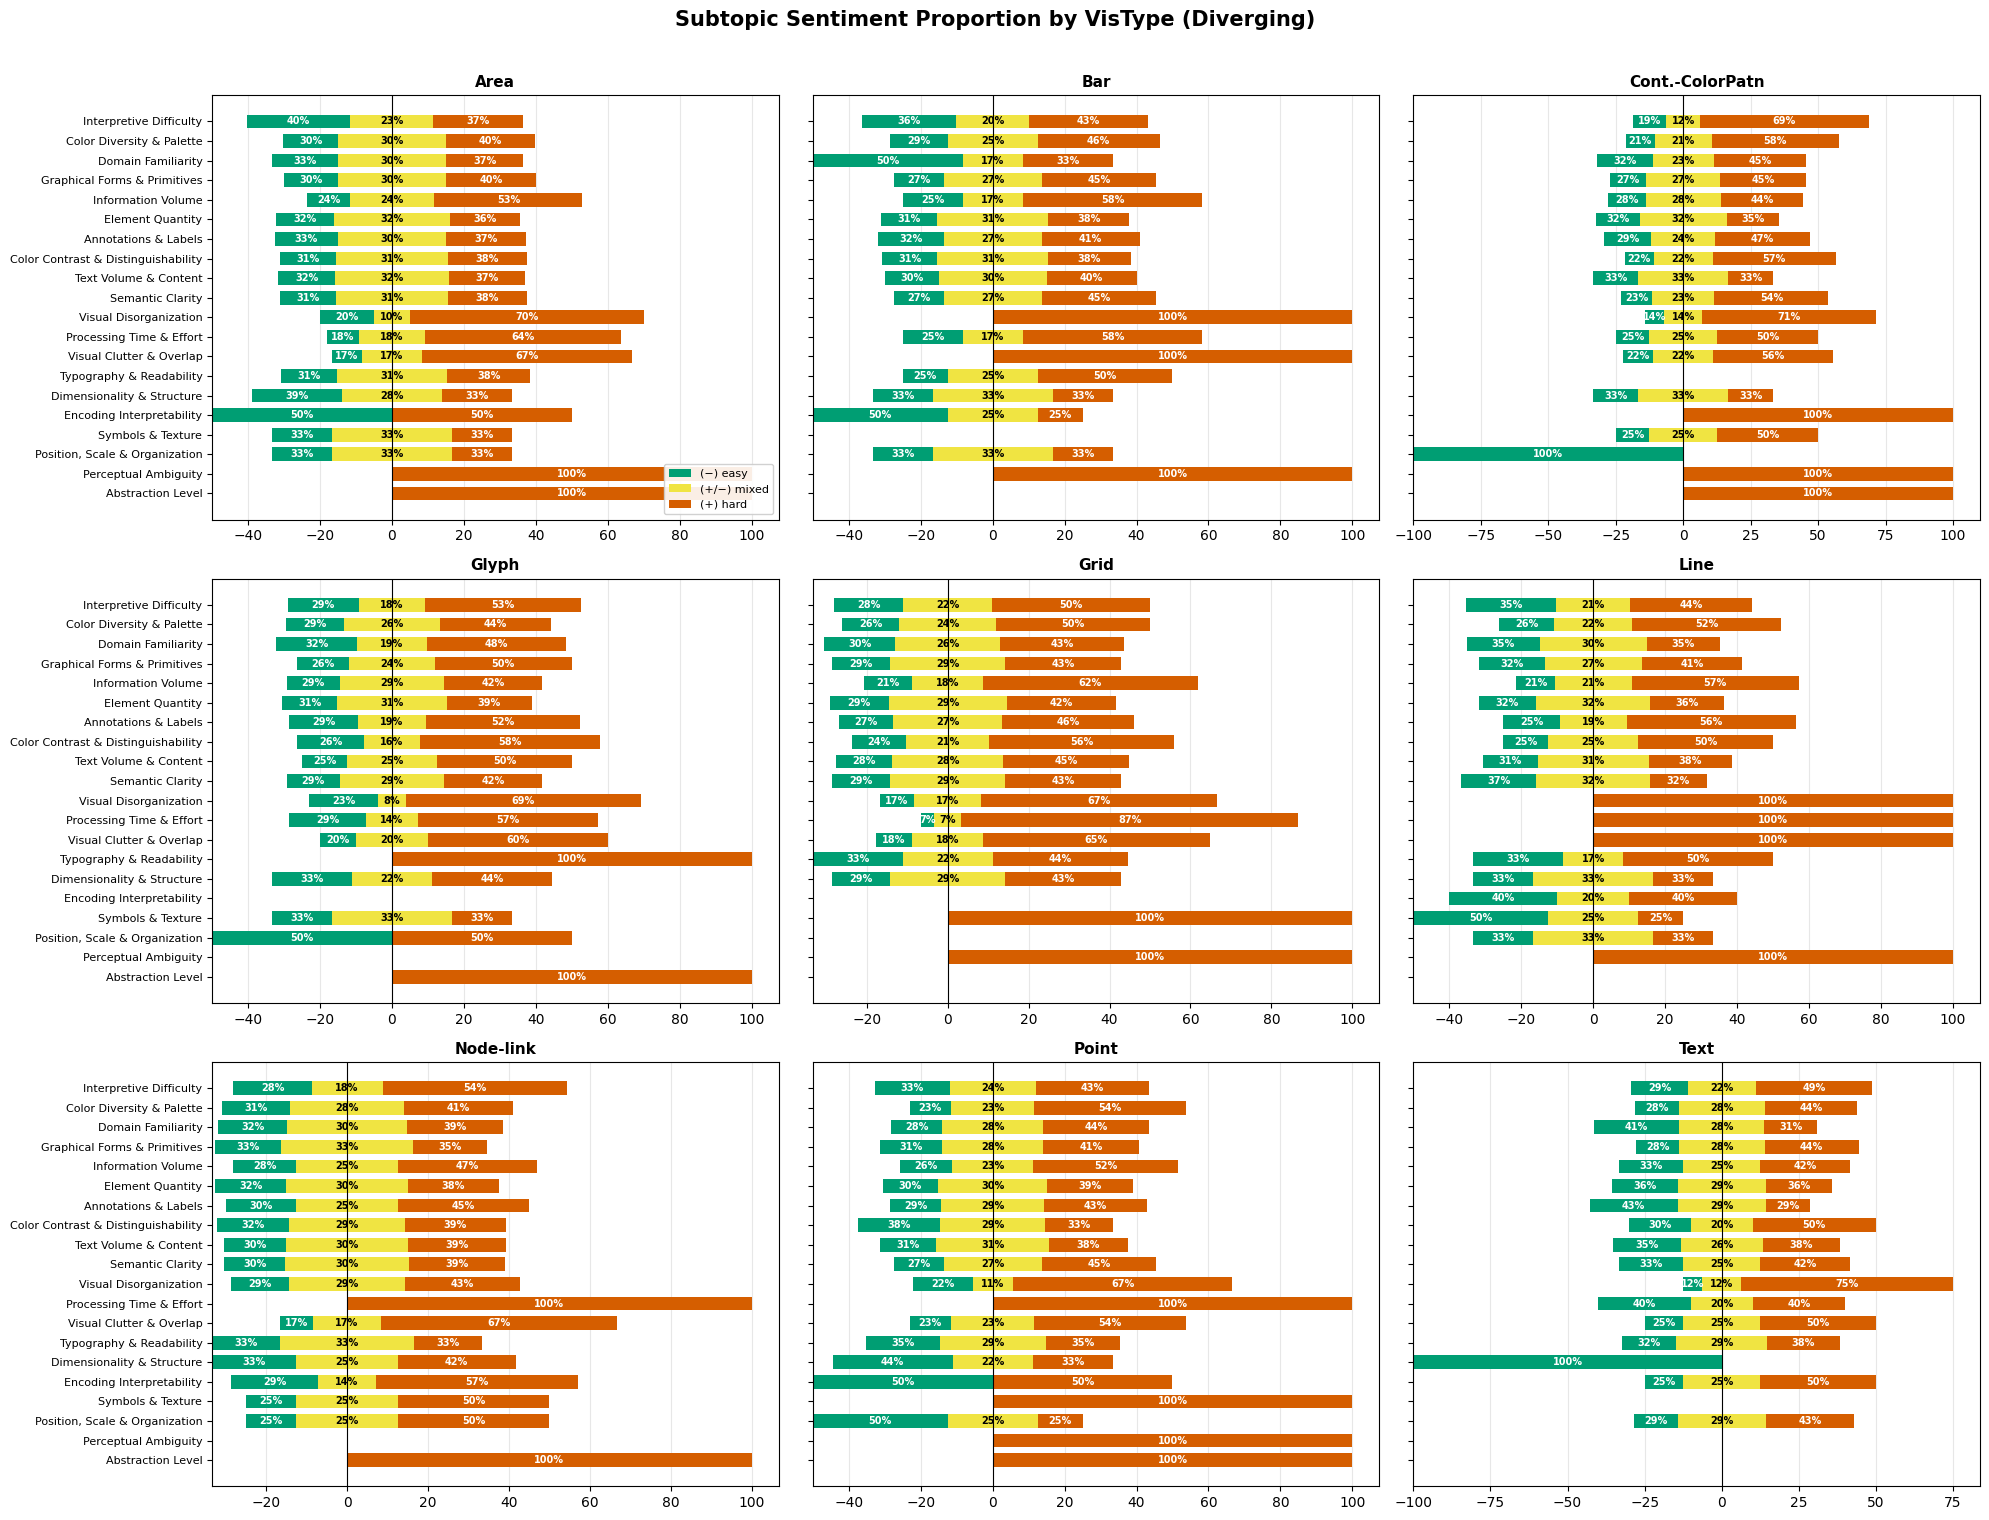

In [32]:
# ── Proportional diverging bar charts: Subtopic sentiment per VisType (3×3) ───
n_vt = len(vistype_names)
ncols = 3
nrows = (n_vt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5), sharey=True)
axes = axes.flatten()

sort_key = df_sent_pivot[[f'{vt} (+)' for vt in vistype_names]].sum(axis=1)
sorted_subtopics = sort_key.sort_values(ascending=True).index.tolist()
y = np.arange(len(sorted_subtopics))
bar_height = 0.7

for idx, vt in enumerate(vistype_names):
    ax = axes[idx]
    pos_raw = df_sent_pivot.loc[sorted_subtopics, f'{vt} (+)'].values.astype(float)
    neg_raw = df_sent_pivot.loc[sorted_subtopics, f'{vt} (-)'].values.astype(float)
    mix_raw = df_sent_pivot.loc[sorted_subtopics, f'{vt} (+/-)'].values.astype(float)
    totals = pos_raw + neg_raw + mix_raw
    totals[totals == 0] = 1  # avoid division by zero

    pos_pct = (pos_raw / totals * 100)
    neg_pct = (neg_raw / totals * 100)
    mix_pct = (mix_raw / totals * 100)

    ax.barh(y, neg_pct, height=bar_height, left=-neg_pct, color=COLOR_NEG, label='(−) easy', zorder=2)
    ax.barh(y, mix_pct, height=bar_height, left=-mix_pct / 2, color=COLOR_MIX, label='(+/−) mixed', zorder=3)
    ax.barh(y, pos_pct, height=bar_height, left=0, color=COLOR_POS, label='(+) hard', zorder=2)

    for i in range(len(sorted_subtopics)):
        half_mix = mix_pct[i] / 2
        if neg_pct[i] > 5:
            label_x = -(half_mix + neg_pct[i]) / 2 if neg_pct[i] > half_mix else -neg_pct[i] / 2
            ax.text(label_x, i, f'{neg_pct[i]:.0f}%', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')
        if mix_pct[i] > 5:
            ax.text(0, i, f'{mix_pct[i]:.0f}%', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black')
        if pos_pct[i] > 5:
            label_x = (half_mix + pos_pct[i]) / 2 if pos_pct[i] > half_mix else pos_pct[i] / 2
            ax.text(label_x, i, f'{pos_pct[i]:.0f}%', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')

    ax.set_yticks(y)
    ax.set_yticklabels(sorted_subtopics, fontsize=8)
    ax.set_title(vt, fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8, zorder=4)
    ax.grid(axis='x', alpha=0.3, zorder=0)

    if idx == 0:
        ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

for idx in range(n_vt, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Subtopic Sentiment Proportion by VisType (Diverging)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phrase_reduction_v2/subtopic_sentiment_proportion_per_vistype.png', dpi=150, bbox_inches='tight')
print('Saved: phrase_reduction_v2/subtopic_sentiment_proportion_per_vistype.png')
plt.show()

### Pivot: top-k phrase image counts by VisType

In [84]:
TOP_K = 20

# Count unique images per (phrase, VisType) using humanCuratedPhrases from mapping table
vt_phrase_images = defaultdict(lambda: defaultdict(set))  # vt → phrase → {imageNames}
phrase_total_images = defaultdict(set)                     # phrase → {imageNames}

for _, row in df_mapping.iterrows():
    vt = row['VisType']
    hc_str = row['humanCuratedPhrases']
    img = row['imageName']

    if not isinstance(vt, str) or not vt.strip():
        continue
    if vt.strip() not in vistype_names:
        continue
    if not isinstance(hc_str, str) or not hc_str.strip():
        continue

    for p in hc_str.split(';'):
        p = p.strip()
        if p and p in phrase_to_subtopic:
            vt_phrase_images[vt.strip()][p].add(img)
            phrase_total_images[p].add(img)

# Rank phrases by total image count, take top k
phrase_ranked = sorted(phrase_total_images.keys(), key=lambda p: len(phrase_total_images[p]), reverse=True)
top_phrases = phrase_ranked[:TOP_K]
print(f'Top {TOP_K} phrases by total image count:')

# Build counts table
topk_rows = []
for phrase in top_phrases:
    # Look up topic and subtopic
    topic, st = phrase_to_subtopic.get(phrase, ('', ''))
    row_data = {'Phrase': phrase, 'Topic': topic, 'SubTopic': st, 'Total': len(phrase_total_images[phrase])}
    for vt in vistype_names:
        row_data[vt] = len(vt_phrase_images[vt].get(phrase, set()))
    topk_rows.append(row_data)

df_topk_counts = pd.DataFrame(topk_rows).set_index('Phrase')

# Total images per VisType (from mapping table, standard 9 only)
vt_total_topk = {vt: df_mapping[df_mapping['VisType'] == vt]['imageName'].nunique() for vt in vistype_names}

# Rename count columns to include total image count
topk_col_map = {vt: f'{vt} ({vt_total_topk[vt]})' for vt in vistype_names}
df_topk_counts = df_topk_counts.rename(columns=topk_col_map)
df_topk_counts.to_csv('phrase_reduction_v2/topk_overall_phrase_vistype_counts.csv')
display(df_topk_counts)

# Percentages: phrase-vistype images / total vistype images
df_topk_pct = df_topk_counts.copy()
df_topk_pct = df_topk_pct.rename(columns={v: k for k, v in topk_col_map.items()})
for vt in vistype_names:
    total = vt_total_topk[vt]
    df_topk_pct[vt] = (df_topk_counts[topk_col_map[vt]] / total * 100).round(1) if total > 0 else 0.0
df_topk_pct.to_csv('phrase_reduction_v2/topk_overall_phrase_vistype_pct.csv')

print(f'\nTop-{TOP_K} phrase × VisType image %')
print('Saved: phrase_reduction_v2/topk_overall_phrase_vistype_counts.csv')

print('Saved: phrase_reduction_v2/topk_overall_phrase_vistype_pct.csv')

Top 20 phrases by total image count:


,Topic,SubTopic,Total,Area (65),Bar (51),Cont.-ColorPatn (42),Glyph (64),Grid (65),Line (48),Node-link (66),Point (58),Text (51)
Phrase,,,,,,,,,,,,
more charts/points/lines/shapes/elements,Data Density / Image Clutter,Element Quantity,78,7,9,9,9,10,7,11,13,3
"domain-specific concepts (e.g., chemical, biology, map)",Schema,Domain Familiarity,41,12,0,3,1,4,5,6,6,4
unclear meaning/confusing,Immediacy / Cognitive Load,Semantic Clarity,29,4,3,3,4,3,5,5,0,2
take longer to interpret,Immediacy / Cognitive Load,Processing Time & Effort,25,5,1,1,2,5,4,3,4,0
shapes and lines,Visual Encoding Clarity,Graphical Forms & Primitives,23,2,2,1,4,0,3,7,3,1
amount of words/context/numbers,Semantics / Text Legibility,Text Volume & Content,22,4,3,0,1,4,1,3,3,3
distracting/confusing/unclear,Aesthetics Uncertainty,Visual Disorganization,21,3,1,3,4,2,4,1,2,1
overlapping shapes/colors/lines,Data Density / Image Clutter,Visual Clutter & Overlap,17,2,0,1,1,0,3,8,2,0
word rotation/small font size,Semantics / Text Legibility,Typography & Readability,17,5,0,0,0,1,0,1,4,6



Top-20 phrase × VisType image %
Saved: phrase_reduction_v2/topk_overall_phrase_vistype_counts.csv
Saved: phrase_reduction_v2/topk_overall_phrase_vistype_pct.csv


In [83]:
# ── Top-20 phrases per VisType (columnar layout) ─────────────────────────────
# Columns: Area, Area(count), Bar, Bar(count), ...
# Each VisType independently lists its top 20 phrases sorted by image count.

TOP_K_PER_VT = 20

# Reuse vt_phrase_images from cell above (vt → phrase → {imageNames})
# Build per-VisType ranked lists
vt_top = {}
for vt in vistype_names:
    phrase_counts = {p: len(imgs) for p, imgs in vt_phrase_images[vt].items()}
    ranked = sorted(phrase_counts.items(), key=lambda x: x[1], reverse=True)[:TOP_K_PER_VT]
    vt_top[vt] = ranked

# Build columnar DataFrame — each VisType gets two columns: phrase name + count
col_data = {}
for vt in vistype_names:
    phrases = [p for p, _ in vt_top[vt]]
    counts = [c for _, c in vt_top[vt]]
    # Pad to TOP_K_PER_VT if fewer phrases exist
    phrases += [''] * (TOP_K_PER_VT - len(phrases))
    counts += [0] * (TOP_K_PER_VT - len(counts))
    col_data[vt] = phrases
    col_data[f'{vt}(count)'] = counts

# Interleave columns: Area, Area(count), Bar, Bar(count), ...
ordered_cols = []
for vt in vistype_names:
    ordered_cols.append(vt)
    ordered_cols.append(f'{vt}(count)')

df_vt_topk = pd.DataFrame(col_data)[ordered_cols]
df_vt_topk.index = range(1, TOP_K_PER_VT + 1)
df_vt_topk.index.name = 'Rank'

csv_path = 'phrase_reduction_v2/top_phrases_per_vistype.csv'
df_vt_topk.to_csv(csv_path)
print(f'Top {TOP_K_PER_VT} phrases per VisType ({len(vistype_names)} VisTypes)')
display(df_vt_topk)
print(f'Saved: {csv_path}')

Top 20 phrases per VisType (9 VisTypes)


,Area,Area(count),Bar,Bar(count),Cont.-ColorPatn,Cont.-ColorPatn(count),Glyph,Glyph(count),Grid,Grid(count),Line,Line(count),Node-link,Node-link(count),Point,Point(count),Text,Text(count)
Rank,,,,,,,,,,,,,,,,,,
1,"domain-specific concepts (e.g., chemical, biol...",12,more charts/points/lines/shapes/elements,9,more charts/points/lines/shapes/elements,9,more charts/points/lines/shapes/elements,9,more charts/points/lines/shapes/elements,10,more charts/points/lines/shapes/elements,7,more charts/points/lines/shapes/elements,11,more charts/points/lines/shapes/elements,13,word rotation/small font size,6
2,more charts/points/lines/shapes/elements,7,unclear meaning/confusing,3,unclear colors/contrast,3,distracting/confusing/unclear,4,take longer to interpret,5,unclear meaning/confusing,5,overlapping shapes/colors/lines,8,"domain-specific concepts (e.g., chemical, biol...",6,"domain-specific concepts (e.g., chemical, biol...",4
3,take longer to interpret,5,amount of words/context/numbers,3,distracting/confusing/unclear,3,unclear meaning/confusing,4,"domain-specific concepts (e.g., chemical, biol...",4,"domain-specific concepts (e.g., chemical, biol...",5,shapes and lines,7,take longer to interpret,4,more charts/points/lines/shapes/elements,3
4,word rotation/small font size,5,shapes and lines,2,"domain-specific concepts (e.g., chemical, biol...",3,shapes and lines,4,amount of words/context/numbers,4,take longer to interpret,4,"domain-specific concepts (e.g., chemical, biol...",6,word rotation/small font size,4,two colors,3
5,amount of words/context/numbers,4,scale difference,1,unclear meaning/confusing,3,inadequate/few coloring,3,read/analyze many figures/items,4,distracting/confusing/unclear,4,unclear meaning/confusing,5,amount of words/context/numbers,3,amount of words/context/numbers,3
6,soft/layered/overlapping colors,4,two colors,1,2D/3D,2,take longer to interpret,2,unclear meaning/confusing,3,shapes and lines,3,amount of words/context/numbers,3,shapes and lines,3,unclear meaning/confusing,2
7,unclear meaning/confusing,4,2D/3D,1,blurry colors/images,2,shape size,2,distinguishable/full/highly contrast color uses,3,overlapping shapes/colors/lines,3,take longer to interpret,3,more parameters/variables,2,simple visual elements,1
8,distracting/confusing/unclear,3,soft/layered/overlapping colors,1,distinguishable/full/highly contrast color uses,1,white/black background / other background,2,more parameters/variables,3,shape increase/decrease point,2,2D/3D,3,distracting/confusing/unclear,2,understand/read shapes,1
9,bright colors,2,more labels/context,1,overlapping shapes/colors/lines,1,symbols,1,inadequate/few coloring,3,clear colors/shapes,1,shape point of interest,2,more labels/context,2,monochrome,1


Saved: phrase_reduction_v2/top_phrases_per_vistype.csv


## Literature Factor Intersection

Cross-reference our stem dictionary with the **visual complexity factors** from
*"What Makes A Visualization Visually Complex"* (Table 1).

For each literature factor, stem its keywords and check which ones appear in our dictionary.

In [137]:
# ── Literature factors from "What Makes A Visualization Visually Complex" ───────
vc_factors = {
    'Information-theoretic': [
        'Entropy', 'Compression ratio', 'Noise', 'Quantity of information',
        'Meaningfulness', 'Understandability', 'Prototypicality',
        'Cognitive load', 'Perceivability of detail',
    ],
    'Clutter': [
        'Clutter', 'Feature congestion', 'Visual clutter',
    ],
    'Color': [
        'Colorfulness', 'Color variability', 'Colors', 'Color regions',
        'Color harmony', 'Color coherence', 'Luminance variations',
        'Gradient strength', 'Saturation complexity', 'Hue complexity',
        'Value complexity', 'Lighting complexity',
    ],
    'Shape and Structure': [
        'Symmetry', 'Organization', 'Spatial Frequency',
        'Variety of visual form', 'Spatial organization', 'Ease of grouping',
        'Grid', 'Edges', 'Edge density', 'Edge congestion', 'Structure',
        'Compactness', 'Turns', 'Skeletons', 'Texture variation',
        'Material complexity', 'Co-occurrence matrix',
    ],
    'Object-based': [
        'Number of objects', 'Object categories', 'Element relationships',
        'Element heterogeneity', 'Element diversity',
    ],
}

# Flatten to a DataFrame
lit_rows = []
for cat, factors in vc_factors.items():
    for factor in factors:
        lit_rows.append({'Category': cat, 'Factor': factor})
df_lit = pd.DataFrame(lit_rows)
print(f'Literature factors: {len(df_lit)} factors across {len(vc_factors)} categories')
df_lit

Literature factors: 46 factors across 5 categories


,Category,Factor
0,Information-theoretic,Entropy
1,Information-theoretic,Compression ratio
2,Information-theoretic,Noise
3,Information-theoretic,Quantity of information
4,Information-theoretic,Meaningfulness
5,Information-theoretic,Understandability
6,Information-theoretic,Prototypicality
7,Information-theoretic,Cognitive load
8,Information-theoretic,Perceivability of detail
9,Clutter,Clutter


In [138]:
# ── Stem each factor and find matches in our dictionary ─────────────────────────
dict_stems = set(df_dict['stem'].str.lower())

def stem_factor(factor_name):
    """Tokenize and stem a factor name, return list of (stem_word, matched) tuples."""
    doc = nlp(factor_name.lower())
    results = []
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space or len(token.text) <= 1:
            continue
        word = token.lemma_.lower()
        stem = stemmer.stem(word)
        rep = stem_to_word.get(stem, word)
        matched = rep.lower() in dict_stems
        results.append((rep, matched))
    return results

# Build intersection table
intersection_rows = []
for _, row in df_lit.iterrows():
    cat = row['Category']
    factor = row['Factor']
    stemmed = stem_factor(factor)
    matched_words = [w for w, m in stemmed if m]
    all_words = [w for w, _ in stemmed]
    unmatched = [w for w, m in stemmed if not m]

    # For matched words, get their image counts from dict
    match_details = []
    for w in matched_words:
        dict_row = df_dict[df_dict['stem'].str.lower() == w.lower()]
        if len(dict_row) > 0:
            count = dict_row.iloc[0]['totalImages']
            match_details.append(f'{w} ({int(count)})')
        else:
            match_details.append(w)

    intersection_rows.append({
        'Category': cat,
        'Factor': factor,
        'factorKeywords': '; '.join(all_words),
        'matchedStems': '; '.join(match_details) if match_details else '',
        'unmatchedKeywords': '; '.join(unmatched) if unmatched else '',
        'matchCount': len(matched_words),
        'totalKeywords': len(all_words),
    })

df_intersection = pd.DataFrame(intersection_rows)

# Summary
n_any_match = (df_intersection['matchCount'] > 0).sum()
n_full_match = (df_intersection['matchCount'] == df_intersection['totalKeywords']).sum()
print(f'Factors with ≥1 stem in our dictionary: {n_any_match}/{len(df_intersection)}')
print(f'Factors fully matched: {n_full_match}/{len(df_intersection)}')
print(f'\nPer category:')
for cat in vc_factors:
    sub = df_intersection[df_intersection['Category'] == cat]
    any_m = (sub['matchCount'] > 0).sum()
    print(f'  {cat}: {any_m}/{len(sub)} factors have matches')

df_intersection

Factors with ≥1 stem in our dictionary: 38/46
Factors fully matched: 26/46

Per category:
  Information-theoretic: 5/9 factors have matches
  Clutter: 3/3 factors have matches
  Color: 12/12 factors have matches
  Shape and Structure: 13/17 factors have matches
  Object-based: 5/5 factors have matches


,Category,Factor,factorKeywords,matchedStems,unmatchedKeywords,matchCount,totalKeywords
0,Information-theoretic,Entropy,entropy,,entropy,0,1
1,Information-theoretic,Compression ratio,compression; ratio,ratio (1),compression,1,2
2,Information-theoretic,Noise,noise,noise (3),,1,1
3,Information-theoretic,Quantity of information,quantity; information,quantity (3); information (79),,2,2
4,Information-theoretic,Meaningfulness,meaningfulness,,meaningfulness,0,1
5,Information-theoretic,Understandability,understand,understand (106),,1,1
6,Information-theoretic,Prototypicality,prototypicality,,prototypicality,0,1
7,Information-theoretic,Cognitive load,cognitive; load,,cognitive; load,0,2
8,Information-theoretic,Perceivability of detail,perceivability; detail,detail (48),perceivability,1,2
9,Clutter,Clutter,clutter,clutter (7),,1,1


In [139]:
# ── Save intersection table ──────────────────────────────────────────────────────
int_path = 'phrase_reduction_v2/literature_factor_intersection.csv'
df_intersection.to_csv(int_path, index=False)
print(f'Saved: {int_path}')

# ── Show which dictionary stems map to literature categories ────────────────────
# Reverse mapping: for each stem in our dict, which lit categories does it relate to?
stem_to_lit_cats = defaultdict(set)
for _, row in df_intersection.iterrows():
    for w in row['matchedStems'].split('; '):
        if not w:
            continue
        # Extract just the word (strip the count in parentheses)
        word = w.split(' (')[0].strip().lower()
        stem_to_lit_cats[word].add(row['Category'])

# Add literature category column to df_dict
df_dict['litCategories'] = df_dict['stem'].apply(
    lambda s: '; '.join(sorted(stem_to_lit_cats.get(s.lower(), set()))) if s.lower() in stem_to_lit_cats else ''
)

n_lit = (df_dict['litCategories'] != '').sum()
print(f'\nStems in dict linked to literature: {n_lit}/{len(df_dict)}')
print(f'\nTop matched stems (by image count) with their literature categories:')
df_dict[df_dict['litCategories'] != ''].sort_values('totalImages', ascending=False).head(20)[
    ['stem', 'POS', 'totalImages', 'litCategories']
]

Saved: phrase_reduction_v2/literature_factor_intersection.csv

Stems in dict linked to literature: 37/668

Top matched stems (by image count) with their literature categories:


,stem,POS,totalImages,litCategories
0,color,"ADJ, NOUN, PROPN, VERB",193,Color
1,understand,"ADJ, NOUN, VERB",106,Information-theoretic
2,information,NOUN,79,Information-theoretic
8,detail,"ADJ, NOUN, PROPN",48,Information-theoretic
11,number,NOUN,47,Object-based
20,element,NOUN,30,Object-based
21,visual,"ADJ, ADV, NOUN, VERB",29,Clutter; Shape and Structure
27,complex,"ADJ, NOUN, PROPN",21,Color; Shape and Structure
56,variable,NOUN,12,Color
75,variety,NOUN,9,Shape and Structure


## Dictionary Analyses

Explore stem distributions across **topics** and **VisTypes**:
1. Top stems per topic & topic-exclusive stems
2. Topic distribution heatmap (top 30 stems)
3. VisType vocabulary profiles
4. VisType Jaccard similarity & exclusive stems

In [140]:
# ── Top 10 stems per topic + topic-exclusive stems ──────────────────────────────
print('='*80)
print('TOP 10 STEMS PER TOPIC (by image count within that topic)')
print('='*80)

for topic in topic_names:
    top = df_dict[df_dict[topic] > 0].nlargest(10, topic)[['stem', topic, 'totalImages', 'POS']]
    print(f'\n■ {topic}')
    for _, r in top.iterrows():
        pct = r[topic] / r['totalImages'] * 100
        print(f'  {r["stem"]:<20s} {int(r[topic]):>4d} images  ({pct:5.1f}% of total {int(r["totalImages"])})')

# Topic exclusivity: stems that appear ONLY in one topic
print('\n' + '='*80)
print('TOPIC-EXCLUSIVE STEMS (appear in only 1 topic, ≥3 images)')
print('='*80)
topic_presence = df_dict[topic_names].gt(0).sum(axis=1)
for topic in topic_names:
    exclusive = df_dict[(topic_presence == 1) & (df_dict[topic] > 0) & (df_dict[topic] >= 3)]
    exclusive = exclusive.nlargest(10, topic)
    print(f'\n■ {topic} ({len(df_dict[(topic_presence == 1) & (df_dict[topic] > 0)])} exclusive stems total)')
    for _, r in exclusive.iterrows():
        print(f'  {r["stem"]:<20s} {int(r[topic]):>4d} images')

TOP 10 STEMS PER TOPIC (by image count within that topic)

■ Data Density / Image Clutter
  color                  96 images  ( 49.7% of total 193)
  information            60 images  ( 75.9% of total 79)
  lot                    49 images  ( 89.1% of total 55)
  understand             48 images  ( 45.3% of total 106)
  detail                 43 images  ( 89.6% of total 48)
  differ                 42 images  ( 67.7% of total 62)
  line                   41 images  ( 65.1% of total 63)
  shape                  40 images  ( 60.6% of total 66)
  datum                  37 images  ( 77.1% of total 48)
  number                 31 images  ( 66.0% of total 47)

■ Visual Encoding Clarity
  color                  86 images  ( 44.6% of total 193)
  shape                  56 images  ( 84.8% of total 66)
  line                   48 images  ( 76.2% of total 63)
  understand             41 images  ( 38.7% of total 106)
  differ                 40 images  ( 64.5% of total 62)
  information           

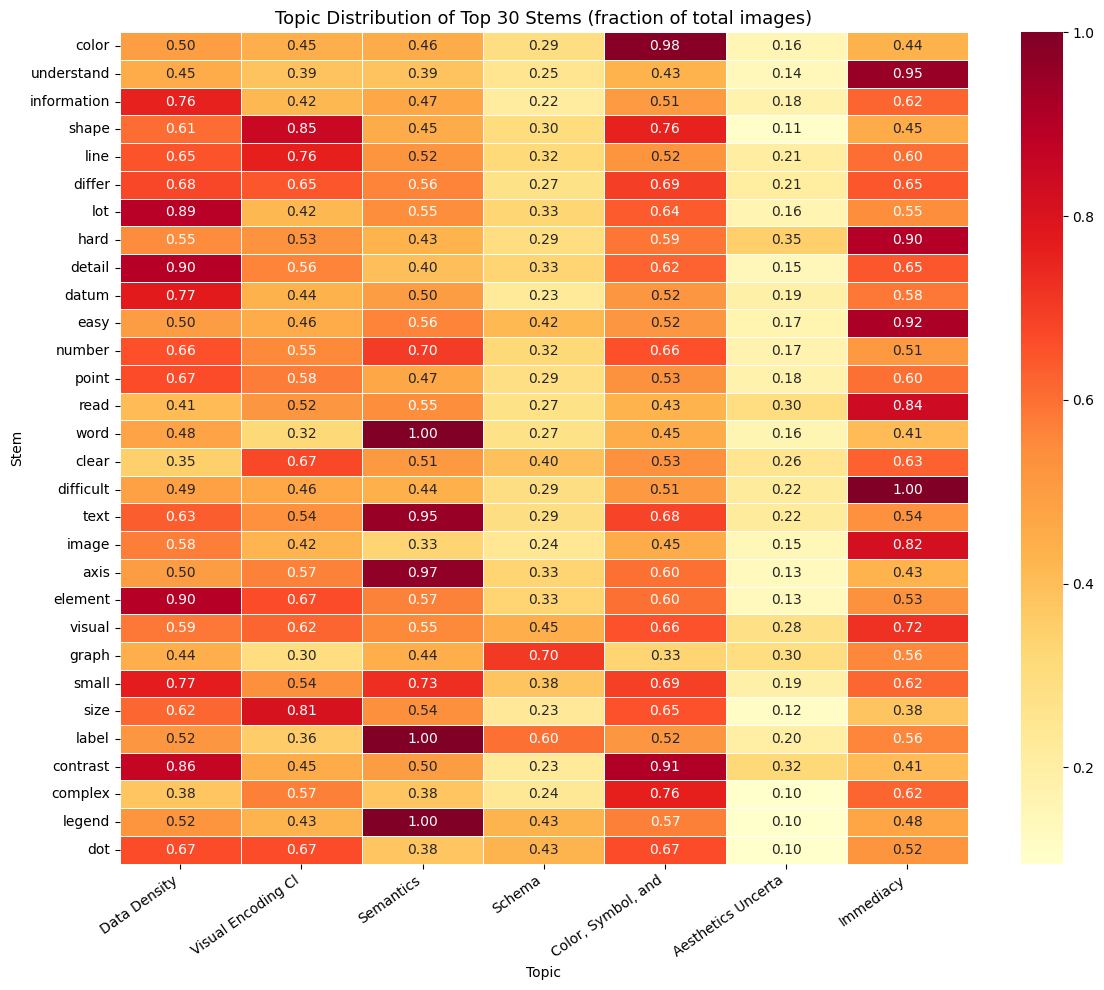

In [141]:
# ── Topic distribution heatmap (top 30 stems) ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

top30 = df_dict.head(30).copy()

# Normalize: fraction of each stem's total that comes from each topic
heat_data = top30[topic_names].div(top30['totalImages'], axis=0)
heat_data.index = top30['stem']

# Short topic labels for display
short_topics = [t.split('/')[0].split(' -')[0].strip()[:18] for t in topic_names]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heat_data.values,
    xticklabels=short_topics,
    yticklabels=heat_data.index,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Topic Distribution of Top 30 Stems (fraction of total images)', fontsize=13)
ax.set_xlabel('Topic')
ax.set_ylabel('Stem')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [142]:
# ── VisType vocabulary profiles ──────────────────────────────────────────────────
CANONICAL_VISTYPES = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
                      'Line', 'Node-link', 'Point', 'Text']

vistype_profiles = []
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    # Collect all stems for this VisType
    all_stems = []
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            all_stems.extend([x.strip() for x in s.split(';') if x.strip()])
    stem_counts = Counter(all_stems)
    unique_count = len(stem_counts)
    top5 = stem_counts.most_common(5)

    vistype_profiles.append({
        'VisType': vt,
        'numImages': len(vt_imgs),
        'uniqueStems': unique_count,
        'stemsPerImage': round(unique_count / max(len(vt_imgs), 1), 1),
        'top5': ', '.join(f'{w} ({c})' for w, c in top5),
    })

df_vt_prof = pd.DataFrame(vistype_profiles)
print('VisType Vocabulary Profiles')
print('='*90)
for _, r in df_vt_prof.iterrows():
    print(f'\n■ {r["VisType"]:<18s}  {r["numImages"]:>3d} images | '
          f'{r["uniqueStems"]:>4d} unique stems | {r["stemsPerImage"]:>5.1f} stems/image')
    print(f'  Top 5: {r["top5"]}')

df_vt_prof

VisType Vocabulary Profiles

■ Area                 66 images |  235 unique stems |   3.6 stems/image
  Top 5: color (31), understand (15), easy (13), differ (11), read (10)

■ Bar                  52 images |  126 unique stems |   2.4 stems/image
  Top 5: color (18), understand (13), lot (7), bar (7), datum (6)

■ Cont.-ColorPatn      42 images |  166 unique stems |   4.0 stems/image
  Top 5: color (28), understand (7), hard (6), shape (6), information (6)

■ Glyph                64 images |  191 unique stems |   3.0 stems/image
  Top 5: color (19), shape (18), understand (15), differ (7), pattern (7)

■ Grid                 65 images |  187 unique stems |   2.9 stems/image
  Top 5: color (28), understand (14), information (13), lot (11), differ (9)

■ Line                 48 images |  154 unique stems |   3.2 stems/image
  Top 5: line (16), color (14), understand (11), number (10), hard (7)

■ Node-link            66 images |  225 unique stems |   3.4 stems/image
  Top 5: color (22),

,VisType,numImages,uniqueStems,stemsPerImage,top5
0,Area,66,235,3.6,"color (31), understand (15), easy (13), differ..."
1,Bar,52,126,2.4,"color (18), understand (13), lot (7), bar (7),..."
2,Cont.-ColorPatn,42,166,4.0,"color (28), understand (7), hard (6), shape (6..."
3,Glyph,64,191,3.0,"color (19), shape (18), understand (15), diffe..."
4,Grid,65,187,2.9,"color (28), understand (14), information (13),..."
5,Line,48,154,3.2,"line (16), color (14), understand (11), number..."
6,Node-link,66,225,3.4,"color (22), line (18), information (15), under..."
7,Point,58,189,3.3,"color (18), shape (14), information (13), poin..."
8,Text,51,131,2.6,"word (23), color (15), understand (10), size (..."


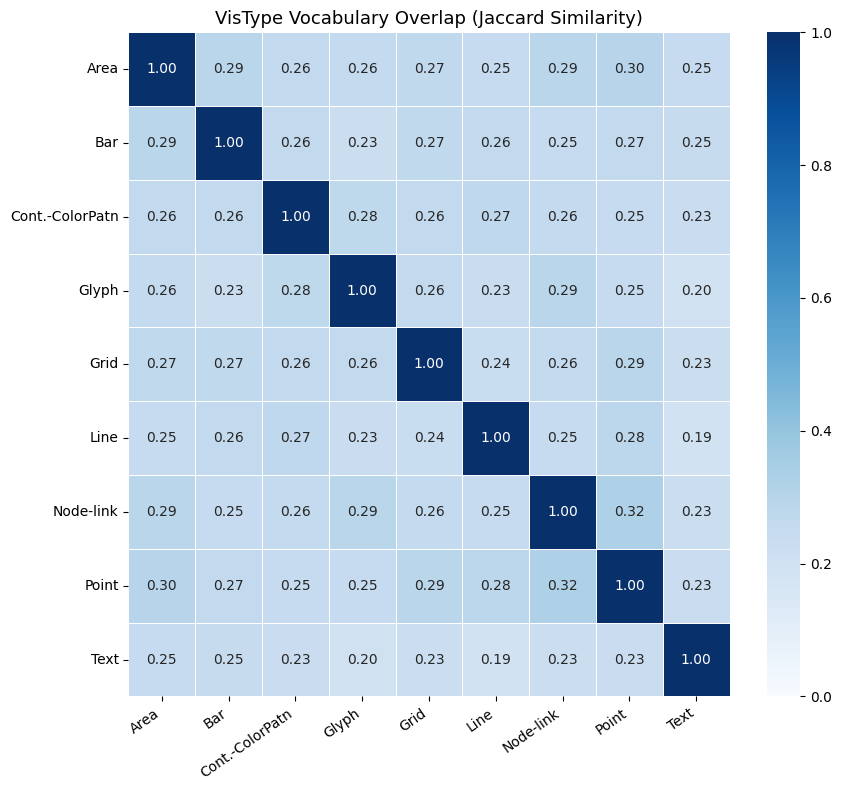


VisType-Exclusive Stems (not in any other VisType):

■ Area: 58 exclusive stems
  physical               2 images
  style                  2 images
  continent              2 images
  grow                   2 images
  geographic             2 images
  soft                   2 images
  pie                    2 images
  bright                 2 images
  varation               1 images
  knowledge              1 images

■ Bar: 20 exclusive stems
  horizontal             2 images
  crop                   1 images
  produce                1 images
  contain                1 images
  extend                 1 images
  gather                 1 images
  grasp                  1 images
  versus                 1 images
  orient                 1 images
  provoke                1 images

■ Cont.-ColorPatn: 35 exclusive stems
  blurry                 2 images
  suppose                2 images
  end                    1 images
  begin                  1 images
  single                 1 images
  e

In [143]:
# ── VisType Jaccard similarity + exclusive stems ────────────────────────────────
import numpy as np

# Build per-VisType stem sets
vt_stem_sets = {}
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    stems = set()
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            stems.update(x.strip() for x in s.split(';') if x.strip())
    vt_stem_sets[vt] = stems

# Jaccard similarity matrix
n = len(CANONICAL_VISTYPES)
jaccard = np.zeros((n, n))
for i, vt1 in enumerate(CANONICAL_VISTYPES):
    for j, vt2 in enumerate(CANONICAL_VISTYPES):
        s1, s2 = vt_stem_sets[vt1], vt_stem_sets[vt2]
        if s1 or s2:
            jaccard[i, j] = len(s1 & s2) / len(s1 | s2)
        else:
            jaccard[i, j] = 0.0

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    jaccard,
    xticklabels=CANONICAL_VISTYPES,
    yticklabels=CANONICAL_VISTYPES,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('VisType Vocabulary Overlap (Jaccard Similarity)', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Exclusive stems per VisType (not in any other VisType)
print('\nVisType-Exclusive Stems (not in any other VisType):')
all_vt_stems = set()
for s in vt_stem_sets.values():
    all_vt_stems.update(s)

for vt in CANONICAL_VISTYPES:
    others = set()
    for vt2 in CANONICAL_VISTYPES:
        if vt2 != vt:
            others.update(vt_stem_sets[vt2])
    exclusive = vt_stem_sets[vt] - others
    print(f'\n■ {vt}: {len(exclusive)} exclusive stems')
    if exclusive:
        # Show top by frequency
        vt_imgs = df_out[df_out['VisType'] == vt]
        exc_counts = Counter()
        for s in vt_imgs['originalStems'].dropna():
            if s.strip():
                for x in s.split(';'):
                    x = x.strip()
                    if x in exclusive:
                        exc_counts[x] += 1
        for w, c in exc_counts.most_common(10):
            print(f'  {w:<20s} {c:>3d} images')

## Dictionary vs. Visual Complexity

Analyze how stems relate to **NormalizedVC** (visual complexity):
1. Per-stem mean VC — which stems are associated with high/low complexity images?
2. VC-discriminating stems — stems that skew toward high or low VC
3. Stem frequency vs. VC correlation
4. High-VC vs. Low-VC vocabulary comparison

In [144]:
# ── Per-stem mean VC ────────────────────────────────────────────────────────────
# For each stem, compute mean NormalizedVC of images that contain it
overall_mean_vc = df_out['NormalizedVC'].mean()

stem_vc_stats = []
for _, drow in df_dict.iterrows():
    stem = drow['stem']
    # Find images containing this stem
    mask = df_out['originalStems'].fillna('').apply(
        lambda s: stem in [x.strip() for x in s.split(';')]
    )
    vc_vals = df_out.loc[mask, 'NormalizedVC'].dropna()
    if len(vc_vals) >= 2:
        stem_vc_stats.append({
            'stem': stem,
            'POS': drow['POS'],
            'totalImages': int(drow['totalImages']),
            'meanVC': vc_vals.mean(),
            'medianVC': vc_vals.median(),
            'stdVC': vc_vals.std(),
            'vcDelta': vc_vals.mean() - overall_mean_vc,  # deviation from global mean
        })

df_stem_vc = pd.DataFrame(stem_vc_stats).sort_values('vcDelta', ascending=False).reset_index(drop=True)

print(f'Overall mean NormalizedVC: {overall_mean_vc:.4f}')
print(f'Stems with ≥2 images: {len(df_stem_vc)}')
print(f'\n── Top 15 HIGH-VC stems (skew toward complex images) ──')
for _, r in df_stem_vc.head(15).iterrows():
    print(f'  {r["stem"]:<20s}  meanVC={r["meanVC"]:.3f}  Δ={r["vcDelta"]:+.3f}  ({r["totalImages"]} imgs)')

print(f'\n── Top 15 LOW-VC stems (skew toward simple images) ──')
for _, r in df_stem_vc.tail(15).iloc[::-1].iterrows():
    print(f'  {r["stem"]:<20s}  meanVC={r["meanVC"]:.3f}  Δ={r["vcDelta"]:+.3f}  ({r["totalImages"]} imgs)')


Overall mean NormalizedVC: 0.5954
Stems with ≥2 images: 344

── Top 15 HIGH-VC stems (skew toward complex images) ──
  grow                  meanVC=0.855  Δ=+0.260  (2 imgs)
  stuff                 meanVC=0.807  Δ=+0.211  (3 imgs)
  ascertain             meanVC=0.797  Δ=+0.201  (3 imgs)
  multitude             meanVC=0.790  Δ=+0.195  (3 imgs)
  vast                  meanVC=0.775  Δ=+0.180  (2 imgs)
  consider              meanVC=0.765  Δ=+0.170  (2 imgs)
  factor                meanVC=0.765  Δ=+0.170  (2 imgs)
  scatter               meanVC=0.762  Δ=+0.167  (4 imgs)
  define                meanVC=0.760  Δ=+0.165  (2 imgs)
  significant           meanVC=0.757  Δ=+0.161  (3 imgs)
  depth                 meanVC=0.755  Δ=+0.160  (2 imgs)
  vertical              meanVC=0.755  Δ=+0.160  (2 imgs)
  suppose               meanVC=0.755  Δ=+0.160  (2 imgs)
  able                  meanVC=0.747  Δ=+0.151  (3 imgs)
  variety               meanVC=0.743  Δ=+0.148  (9 imgs)

── Top 15 LOW-VC stems (ske

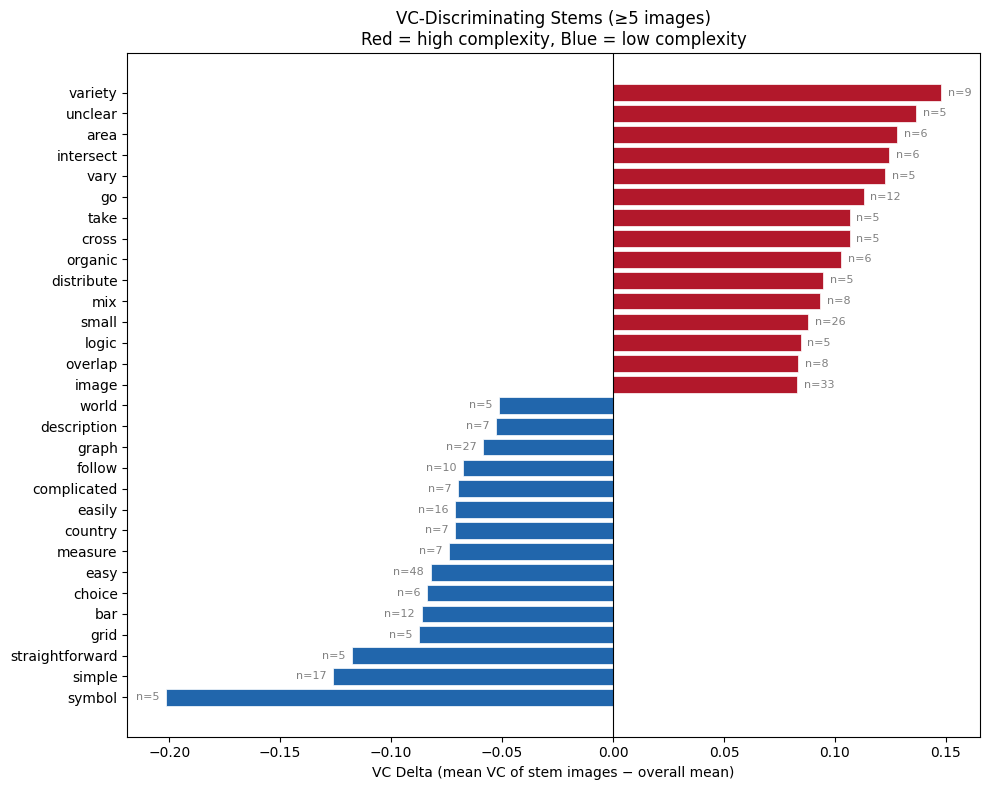

Stems shown: 30 (top/bottom 15 by VC delta, ≥5 images)


In [145]:
# ── VC-discriminating stems: diverging bar chart ────────────────────────────────
# Show stems with largest positive and negative VC delta (≥5 images for reliability)
reliable = df_stem_vc[df_stem_vc['totalImages'] >= 5].copy()

top_high = reliable.nlargest(15, 'vcDelta')
top_low = reliable.nsmallest(15, 'vcDelta')
plot_df = pd.concat([top_high, top_low]).drop_duplicates('stem').sort_values('vcDelta')

colors = ['#2166ac' if d < 0 else '#b2182b' for d in plot_df['vcDelta']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['stem'], plot_df['vcDelta'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('VC Delta (mean VC of stem images − overall mean)')
ax.set_title('VC-Discriminating Stems (≥5 images)\nRed = high complexity, Blue = low complexity', fontsize=12)

# Annotate with image count
for bar, (_, r) in zip(bars, plot_df.iterrows()):
    x = bar.get_width()
    offset = 0.003 if x >= 0 else -0.003
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height()/2, f'n={r["totalImages"]}',
            va='center', ha=ha, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print(f'Stems shown: {len(plot_df)} (top/bottom 15 by VC delta, ≥5 images)')


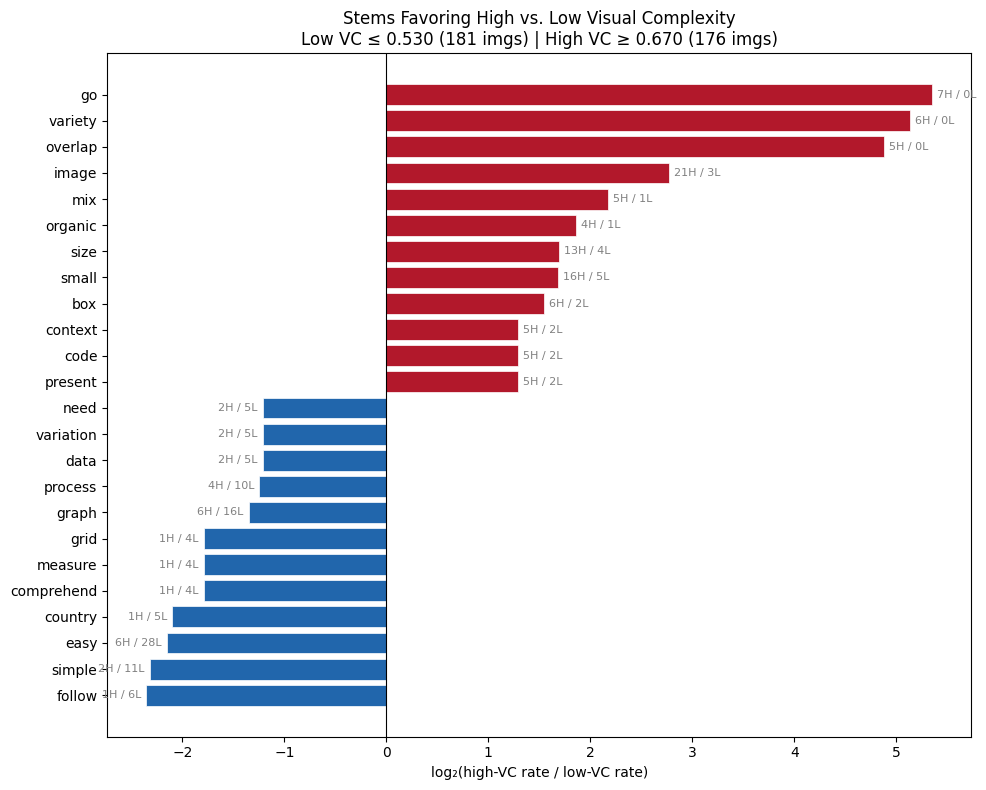


Vocabulary overlap:
  Shared stems: 189
  Only in low-VC images: 176
  Only in high-VC images: 200
  Jaccard similarity: 0.335


In [146]:
# ── High-VC vs. Low-VC vocabulary comparison ────────────────────────────────────
# Split images into terciles by NormalizedVC
vc_sorted = df_out['NormalizedVC'].dropna().sort_values()
low_thresh = vc_sorted.quantile(0.33)
high_thresh = vc_sorted.quantile(0.67)

df_low = df_out[df_out['NormalizedVC'] <= low_thresh]
df_high = df_out[df_out['NormalizedVC'] >= high_thresh]

def collect_stems(df_subset):
    counts = Counter()
    for s in df_subset['originalStems'].dropna():
        if s.strip():
            for x in s.split(';'):
                x = x.strip()
                if x:
                    counts[x] += 1
    return counts

low_counts = collect_stems(df_low)
high_counts = collect_stems(df_high)
all_vc_stems = set(low_counts.keys()) | set(high_counts.keys())

# Compute log-ratio: log2(high_freq / low_freq), with smoothing
vc_comparison = []
for stem in all_vc_stems:
    lc = low_counts.get(stem, 0)
    hc = high_counts.get(stem, 0)
    # Normalize by group size
    low_rate = lc / max(len(df_low), 1)
    high_rate = hc / max(len(df_high), 1)
    # Log ratio with smoothing
    log_ratio = np.log2((high_rate + 0.001) / (low_rate + 0.001))
    vc_comparison.append({
        'stem': stem,
        'lowVC_count': lc,
        'highVC_count': hc,
        'lowVC_rate': low_rate,
        'highVC_rate': high_rate,
        'logRatio': log_ratio,
        'total': lc + hc,
    })

df_vc_comp = pd.DataFrame(vc_comparison)
df_vc_comp = df_vc_comp[df_vc_comp['total'] >= 5]  # reliable only

# Plot top stems favoring high vs low VC
top_high_vc = df_vc_comp.nlargest(12, 'logRatio')
top_low_vc = df_vc_comp.nsmallest(12, 'logRatio')
plot_vc = pd.concat([top_high_vc, top_low_vc]).drop_duplicates('stem').sort_values('logRatio')

colors_vc = ['#2166ac' if lr < 0 else '#b2182b' for lr in plot_vc['logRatio']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_vc['stem'], plot_vc['logRatio'], color=colors_vc, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('log₂(high-VC rate / low-VC rate)')
ax.set_title(f'Stems Favoring High vs. Low Visual Complexity\n'
             f'Low VC ≤ {low_thresh:.3f} ({len(df_low)} imgs) | High VC ≥ {high_thresh:.3f} ({len(df_high)} imgs)',
             fontsize=12)

for bar, (_, r) in zip(bars, plot_vc.iterrows()):
    x = bar.get_width()
    offset = 0.05 if x >= 0 else -0.05
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            f'{int(r["highVC_count"])}H / {int(r["lowVC_count"])}L',
            va='center', ha=ha, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Summary stats
shared = set(low_counts.keys()) & set(high_counts.keys())
only_low = set(low_counts.keys()) - set(high_counts.keys())
only_high = set(high_counts.keys()) - set(low_counts.keys())
print(f'\nVocabulary overlap:')
print(f'  Shared stems: {len(shared)}')
print(f'  Only in low-VC images: {len(only_low)}')
print(f'  Only in high-VC images: {len(only_high)}')
print(f'  Jaccard similarity: {len(shared)/len(shared | only_low | only_high):.3f}')


## Visual Complexity by Topic & VisType

How does **NormalizedVC** distribute across topics and VisTypes?
Which stems discriminate VC *within* each topic or VisType (not just globally)?

C:\Users\mling\AppData\Local\Temp\ipykernel_26860\2894436088.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_topic_vc, y='Topic', x='NormalizedVC', order=order_topic,
C:\Users\mling\AppData\Local\Temp\ipykernel_26860\2894436088.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_vt_vc, y='VisType', x='NormalizedVC', order=order_vt,


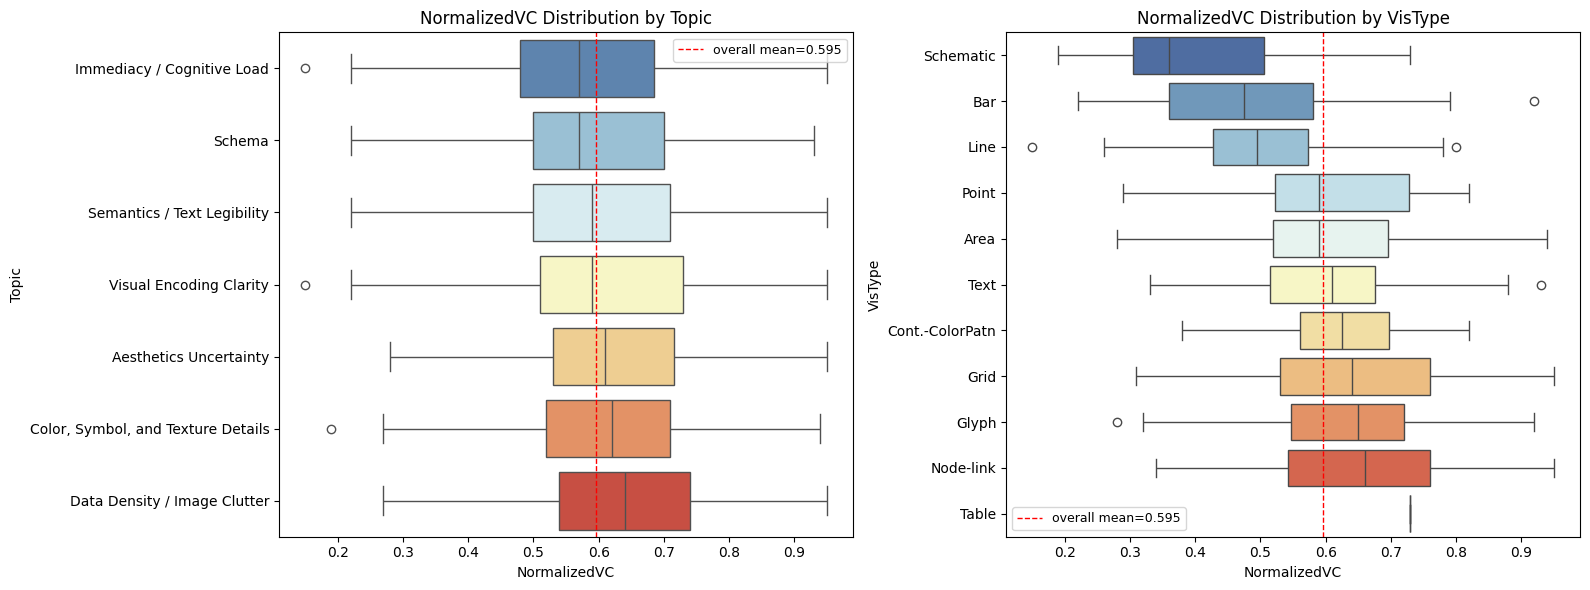

Topic VC Summary:
  Topic                                    mean median    std     n
  Immediacy / Cognitive Load              0.576  0.570  0.157   259
  Schema                                  0.591  0.570  0.150   125
  Semantics / Text Legibility             0.597  0.590  0.146   190
  Visual Encoding Clarity                 0.600  0.590  0.155   182
  Aesthetics Uncertainty                  0.622  0.610  0.137    55
  Color, Symbol, and Texture Details      0.611  0.620  0.145   230
  Data Density / Image Clutter            0.633  0.640  0.146   209

VisType VC Summary:
  VisType                mean median    std     n
  Schematic             0.414  0.360  0.180     7
  Bar                   0.491  0.475  0.159    52
  Line                  0.504  0.495  0.134    48
  Point                 0.602  0.590  0.131    58
  Area                  0.592  0.590  0.141    66
  Text                  0.605  0.610  0.130    51
  Cont.-ColorPatn       0.623  0.625  0.105    42
  Grid           

In [147]:
# ── VC distribution per Topic ────────────────────────────────────────────────────
# Each image can have multiple topics; explode to get per-topic VC stats
df_topic_vc = df_out[['NormalizedVC', 'Topics']].dropna().copy()
df_topic_vc['TopicList'] = df_topic_vc['Topics'].str.split(';')
df_topic_vc = df_topic_vc.explode('TopicList')
df_topic_vc['Topic'] = df_topic_vc['TopicList'].str.strip()
df_topic_vc = df_topic_vc[df_topic_vc['Topic'].isin(topic_names)]

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topic boxplot
order_topic = df_topic_vc.groupby('Topic')['NormalizedVC'].median().sort_values().index.tolist()
sns.boxplot(data=df_topic_vc, y='Topic', x='NormalizedVC', order=order_topic,
            palette='RdYlBu_r', ax=axes[0])
axes[0].axvline(overall_mean_vc, color='red', ls='--', lw=1, label=f'overall mean={overall_mean_vc:.3f}')
axes[0].set_title('NormalizedVC Distribution by Topic', fontsize=12)
axes[0].legend(fontsize=9)

# VisType boxplot
df_vt_vc = df_out[['NormalizedVC', 'VisType']].dropna()
order_vt = df_vt_vc.groupby('VisType')['NormalizedVC'].median().sort_values().index.tolist()
sns.boxplot(data=df_vt_vc, y='VisType', x='NormalizedVC', order=order_vt,
            palette='RdYlBu_r', ax=axes[1])
axes[1].axvline(overall_mean_vc, color='red', ls='--', lw=1, label=f'overall mean={overall_mean_vc:.3f}')
axes[1].set_title('NormalizedVC Distribution by VisType', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Stats table
print('Topic VC Summary:')
print(f'  {"Topic":<38s} {"mean":>6s} {"median":>6s} {"std":>6s} {"n":>5s}')
for topic in order_topic:
    sub = df_topic_vc[df_topic_vc['Topic'] == topic]['NormalizedVC']
    print(f'  {topic:<38s} {sub.mean():6.3f} {sub.median():6.3f} {sub.std():6.3f} {len(sub):5d}')

print(f'\nVisType VC Summary:')
print(f'  {"VisType":<20s} {"mean":>6s} {"median":>6s} {"std":>6s} {"n":>5s}')
for vt in order_vt:
    sub = df_vt_vc[df_vt_vc['VisType'] == vt]['NormalizedVC']
    print(f'  {vt:<20s} {sub.mean():6.3f} {sub.median():6.3f} {sub.std():6.3f} {len(sub):5d}')

In [148]:
# ── VC-discriminating stems WITHIN each topic ───────────────────────────────────
# For each topic, find stems whose images have significantly higher/lower VC
# compared to the topic's own mean VC

print('VC-DISCRIMINATING STEMS WITHIN EACH TOPIC')
print('(stems whose images deviate most from the topic mean VC, ≥3 images in topic)')
print('='*90)

topic_vc_stems = {}  # topic → DataFrame of stem VC stats
for topic in topic_names:
    # Get images in this topic
    topic_mask = df_out['Topics'].fillna('').str.contains(topic.replace('/', '\\/'), regex=False)
    topic_imgs = df_out[topic_mask]
    topic_mean = topic_imgs['NormalizedVC'].mean()

    rows = []
    for _, drow in df_dict[df_dict[topic] >= 3].iterrows():
        stem = drow['stem']
        # Find images in this topic that contain this stem
        stem_mask = topic_imgs['originalStems'].fillna('').apply(
            lambda s: stem in [x.strip() for x in s.split(';')]
        )
        vc_vals = topic_imgs.loc[stem_mask, 'NormalizedVC'].dropna()
        if len(vc_vals) >= 3:
            rows.append({
                'stem': stem,
                'nInTopic': len(vc_vals),
                'meanVC': vc_vals.mean(),
                'topicDelta': vc_vals.mean() - topic_mean,
            })

    if rows:
        df_t = pd.DataFrame(rows).sort_values('topicDelta', ascending=False)
        topic_vc_stems[topic] = df_t

        print(f'\n■ {topic}  (topic mean VC = {topic_mean:.3f}, {len(topic_imgs)} images)')
        print(f'  {"HIGH-VC stems":<35s}  {"LOW-VC stems"}')
        top_h = df_t.head(5)
        top_l = df_t.tail(5).iloc[::-1]
        for (_, h), (_, l) in zip(top_h.iterrows(), top_l.iterrows()):
            print(f'  {h["stem"]:<15s} Δ={h["topicDelta"]:+.3f} (n={h["nInTopic"]:>2d})  │  '
                  f'{l["stem"]:<15s} Δ={l["topicDelta"]:+.3f} (n={l["nInTopic"]:>2d})')

VC-DISCRIMINATING STEMS WITHIN EACH TOPIC
(stems whose images deviate most from the topic mean VC, ≥3 images in topic)

■ Visual Encoding Clarity  (topic mean VC = 0.600, 182 images)
  HIGH-VC stems                        LOW-VC stems
  cross           Δ=+0.160 (n= 4)  │  numerous        Δ=-0.173 (n= 3)
  distinguish     Δ=+0.147 (n= 3)  │  choice          Δ=-0.146 (n= 3)
  figure          Δ=+0.134 (n= 3)  │  straightforward Δ=-0.140 (n= 4)
  abstract        Δ=+0.134 (n= 3)  │  show            Δ=-0.135 (n= 6)
  area            Δ=+0.126 (n= 5)  │  way             Δ=-0.124 (n= 5)

■ Schema  (topic mean VC = 0.591, 125 images)
  HIGH-VC stems                        LOW-VC stems
  figure          Δ=+0.219 (n= 3)  │  bar             Δ=-0.205 (n= 5)
  go              Δ=+0.177 (n= 4)  │  straightforward Δ=-0.131 (n= 4)
  area            Δ=+0.164 (n= 4)  │  simple          Δ=-0.129 (n= 8)
  variety         Δ=+0.131 (n= 5)  │  follow          Δ=-0.109 (n= 5)
  fine            Δ=+0.126 (n= 3)  │

In [149]:
# ── VC-discriminating stems WITHIN each VisType ─────────────────────────────────
print('VC-DISCRIMINATING STEMS WITHIN EACH VISTYPE')
print('(stems whose images deviate most from the VisType mean VC, ≥3 images)')
print('='*90)

vistype_vc_stems = {}
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    vt_mean = vt_imgs['NormalizedVC'].mean()

    rows = []
    # Get stems present in this VisType
    vt_all_stems = Counter()
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            for x in s.split(';'):
                x = x.strip()
                if x:
                    vt_all_stems[x] += 1

    for stem, cnt in vt_all_stems.items():
        if cnt < 3:
            continue
        stem_mask = vt_imgs['originalStems'].fillna('').apply(
            lambda s, st=stem: st in [x.strip() for x in s.split(';')]
        )
        vc_vals = vt_imgs.loc[stem_mask, 'NormalizedVC'].dropna()
        if len(vc_vals) >= 3:
            rows.append({
                'stem': stem,
                'nInVT': len(vc_vals),
                'meanVC': vc_vals.mean(),
                'vtDelta': vc_vals.mean() - vt_mean,
            })

    if rows:
        df_v = pd.DataFrame(rows).sort_values('vtDelta', ascending=False)
        vistype_vc_stems[vt] = df_v

        print(f'\n■ {vt:<18s}  (VisType mean VC = {vt_mean:.3f}, {len(vt_imgs)} images)')
        top_h = df_v.head(5)
        top_l = df_v.tail(5).iloc[::-1]
        print(f'  {"HIGH-VC stems":<35s}  {"LOW-VC stems"}')
        for (_, h), (_, l) in zip(top_h.iterrows(), top_l.iterrows()):
            print(f'  {h["stem"]:<15s} Δ={h["vtDelta"]:+.3f} (n={h["nInVT"]:>2d})  │  '
                  f'{l["stem"]:<15s} Δ={l["vtDelta"]:+.3f} (n={l["nInVT"]:>2d})')

VC-DISCRIMINATING STEMS WITHIN EACH VISTYPE
(stems whose images deviate most from the VisType mean VC, ≥3 images)

■ Area                (VisType mean VC = 0.592, 66 images)
  HIGH-VC stems                        LOW-VC stems
  size            Δ=+0.148 (n= 6)  │  easily          Δ=-0.132 (n= 3)
  value           Δ=+0.145 (n= 3)  │  chart           Δ=-0.122 (n= 4)
  multiple        Δ=+0.112 (n= 3)  │  world           Δ=-0.109 (n= 4)
  small           Δ=+0.110 (n= 7)  │  recognize       Δ=-0.102 (n= 3)
  image           Δ=+0.093 (n= 4)  │  country         Δ=-0.102 (n= 3)

■ Bar                 (VisType mean VC = 0.491, 52 images)
  HIGH-VC stems                        LOW-VC stems
  require         Δ=+0.149 (n= 3)  │  simple          Δ=-0.191 (n= 3)
  element         Δ=+0.129 (n= 4)  │  easy            Δ=-0.123 (n= 6)
  line            Δ=+0.116 (n= 4)  │  bar             Δ=-0.097 (n= 7)
  complex         Δ=+0.106 (n= 4)  │  graph           Δ=-0.095 (n= 5)
  lot             Δ=+0.099 (n= 7

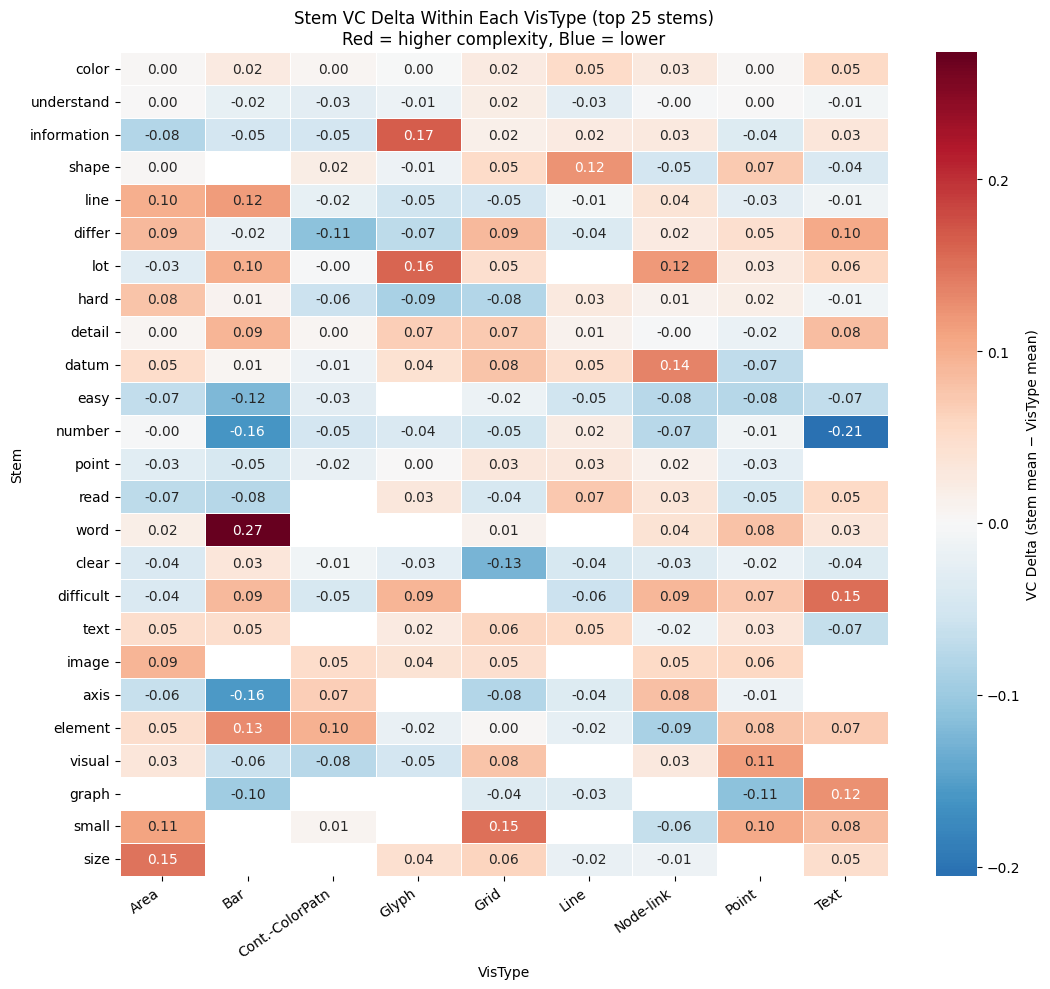

In [150]:
# ── Stem × VisType VC-delta heatmap ──────────────────────────────────────────────
# For top 25 most frequent stems, show their VC delta within each VisType
top_stems = df_dict.head(25)['stem'].tolist()

heat_rows = []
for stem in top_stems:
    row = {'stem': stem}
    for vt in CANONICAL_VISTYPES:
        vt_imgs = df_out[df_out['VisType'] == vt]
        vt_mean = vt_imgs['NormalizedVC'].mean()
        mask = vt_imgs['originalStems'].fillna('').apply(
            lambda s, st=stem: st in [x.strip() for x in s.split(';')]
        )
        vc_vals = vt_imgs.loc[mask, 'NormalizedVC'].dropna()
        row[vt] = (vc_vals.mean() - vt_mean) if len(vc_vals) >= 2 else np.nan
    heat_rows.append(row)

df_heat = pd.DataFrame(heat_rows).set_index('stem')

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    df_heat.values,
    xticklabels=CANONICAL_VISTYPES,
    yticklabels=df_heat.index,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.isnan(df_heat.values),
    ax=ax,
    cbar_kws={'label': 'VC Delta (stem mean − VisType mean)'},
)
ax.set_title('Stem VC Delta Within Each VisType (top 25 stems)\nRed = higher complexity, Blue = lower', fontsize=12)
ax.set_xlabel('VisType')
ax.set_ylabel('Stem')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()